In [1]:
# This code is written by Nooshin Abdollahi
# Information about this code:
# - Motor axons are not included
# - there are not transverse connections between Boundary and Boundary

In [2]:
# show the time of execution
from datetime import datetime
start_time = datetime.now()


In [3]:
from neuron import h
import netpyne 
from netpyne import specs, sim   
import matplotlib.pyplot as plt
import numpy as np
from typing import Tuple, List
import math
import sys


%matplotlib inline

In [4]:
# Import nesseccery files from Matlab

R = np.loadtxt("R.txt")    # All axons with different radius
G = np.loadtxt("G.txt")    # Axon's groups
C = np.loadtxt("C.txt")    # Coordinates of each axon (x,y)
neighboringAxon = np.loadtxt("neighboringAxon.txt")
dist = np.loadtxt("dist.txt")    
dist_edge = np.loadtxt("Distance_edge.txt") 
AVE_area_around_axon = np.loadtxt("Ave_area_around_axon.txt")

unique_radius = np.loadtxt("unique_radius.txt")          # including different types
Number_of_nodes = np.loadtxt("Number_of_nodes.txt")      # Number of nodes for the specified axon total length

parameters = np.loadtxt("parameters.txt")  

# importing all the connections
import scipy.io as io

for i in range(1,2):
    for j in range(1,2):
        if j>=i:
            l = [i, j]
            z = ''.join([str(n) for n in l])
            Input = io.loadmat('Connect_types_{}.mat'.format(z) , squeeze_me=True)  
            I = Input['SAVE']; 
            locals()["Connect_types_"+str(z)]=[]
            for v in range(len(I)):
                D = I[v].strip()  
                locals()["Connect_types_"+str(z)].append(D)  


# Boundary connections
for i in range(1,2):
    Input = io.loadmat('Boundary_to_{}.mat'.format(i) , squeeze_me=True)  
    I = Input['SAVE']; 
    locals()["Boundary_to_"+str(i)]=[]
    for v in range(len(I)):
        D = I[v].strip()  
        locals()["Boundary_to_"+str(i)].append(D) 
    


#
Boundary_coordinates = np.loadtxt("Boundary_coordinates.txt")
Boundary_neighboring = np.loadtxt("Boundary_neighboring.txt")
Boundary_dist = np.loadtxt("Boundary_dist.txt") 


############## importing files related to transverse resistance (Rg) and Areas

for i in range(1,2):
    for j in range(1,2):
        if j>=i:
            l = [i, j]
            z = ''.join([str(n) for n in l])
            Input = np.loadtxt('Rg_{}.txt'.format(z) )  
            locals()["Rg_"+str(z)]=Input
  


                
for i in range(1,2):
    Input = np.loadtxt('Boundary_Rg_{}.txt'.format(i) )  
    locals()["Boundary_Rg_"+str(i)]=Input

    
    
        
        
for i in range(1,2):
    for j in range(1,2):
        if j>i:
            l = [i, j]
            z = ''.join([str(n) for n in l])
            Input = np.loadtxt('Areas_{}.txt'.format(z) )  
            locals()["Areas_"+str(z)]=Input
            
            
            
            


In [5]:
# Network parameters
netParams = specs.NetParams()

netParams.sizeX=3000
netParams.sizeY=3000
netParams.sizeZ=3000


################################# Importing Axons(including C fibers and the others) and Boundary ####################################

netParams.importCellParams(
    cellInstance=True,
    label='Boundary', 
    conds={'cellType': 'Boundary', 'cellModel': 'Boundary'},
    fileName='Boundarycable.hoc', 
    cellName='Boundary', 
    importSynMechs=True) ;




# Myelinated axons have different types (i.e. diameters)
# How many types... do I have?  print(len(unique_radius)-1),  -1 because the first eleman is for C fiber
# each type is a specific diameter

netParams.importCellParams(
    cellInstance=True,
    label='type1', 
    conds={'cellType': 'type1', 'cellModel': 'type1'},
    fileName='type1.hoc', 
    cellName='type1', 
    importSynMechs=True) ;



	1 
	1 


In [6]:
###################################### Locating each axon in specific (x,y) #################################################



netParams.popParams["Axon0"] = {
    'cellType': 'type1', 
    'numCells':1 ,                                         
    'cellModel': 'type1', 
    'xRange':[C[0][0], C[0][0]], 
    'yRange':[0, 0], 
    'zRange':[C[0][1], C[0][1]]} 

netParams.popParams["Axon1"] = {
    'cellType': 'type1', 
    'numCells':1 ,                                         
    'cellModel': 'type1', 
    'xRange':[C[1][0], C[1][0]], 
    'yRange':[0, 0], 
    'zRange':[C[1][1], C[1][1]]}
                    
        
        
        
        
########################################### Locating Boundary Cables ########################################################



    
netParams.popParams["Boundary0"] = {
    'cellType': 'Boundary', 
    'numCells':1 ,                                         
    'cellModel': 'Boundary', 
    'xRange':[Boundary_coordinates[0][0], Boundary_coordinates[0][0]], 
    'yRange':[0, 0], 
    'zRange':[Boundary_coordinates[0][1], Boundary_coordinates[0][1]]} 


                    
    
netParams.popParams["Boundary1"] = {
    'cellType': 'Boundary', 
    'numCells':1 ,                                         
    'cellModel': 'Boundary', 
    'xRange':[Boundary_coordinates[1][0], Boundary_coordinates[1][0]], 
    'yRange':[0, 0], 
    'zRange':[Boundary_coordinates[1][1], Boundary_coordinates[1][1]]} 

                    
                    

# in Total, how many Cells does Netpyne generate?  Length(R)+len(Boundary_coordinates)
print(len(R)+len(Boundary_coordinates))



4


In [7]:
################################################### Stimulation ############################################################
# Which group of axons do you want to stimulate?
# Group1: motor axons   Group2: C fibers    Group3: Adelta     Group4: Abeta


#netParams.stimSourceParams['Input1'] = {'type': 'IClamp', 'del': 1, 'dur': 0.1, 'amp': 0.4}
netParams.stimSourceParams['Input1'] = {'type': 'VClamp', 'dur': [1, 0.02, 0], 'amp':[-80, 0, 0]}

 
netParams.stimTargetParams['Input1->Stim_1'] = {'source': 'Input1', 'sec':'node_0', 'loc': 0.5, 'conds': {'pop':"Axon0"}}    
#netParams.stimTargetParams['Input1->Stim_2'] = {'source': 'Input1', 'sec':'node_0', 'loc': 0.5, 'conds': {'pop':"Axon1"}}       




XG1 = 1e-9     # 1e-9: disconnect from ground     1e9: Connect to ground




In [8]:
simConfig = specs.SimConfig()
simConfig.hParams = {'celsius': 37 }

simConfig.dt = 0.005            # Internal integration timestep to use default is 0.025
simConfig.duration = 6
simConfig.recordStim = True
simConfig.recordStep = 0.005       # Step size in ms to save data (e.g. V traces, LFP, etc) default is 0.1
#simConfig.cache_efficient = True
#simConfig.cvode_active = True
# simConfig.cvode_atol=0.0001
# simConfig.cvode_rtol=0.0001


simConfig.recordTraces = {'V_node_0' :{'sec':'node_0','loc':0.5,'var':'v'}}
simConfig.analysis['plotTraces'] = {'include':  ['allCells']}                              # ['Axon0','Axon1']

simConfig.analysis['plot2Dnet'] = True
simConfig.analysis['plot2Dnet'] = {'include': ['allCells'], 'view': 'xz'}



#simConfig.recordLFP = [[56.39,-4000,51.74]]     # Determine the location of the LFP electrode






sim.create(netParams, simConfig)





Start time:  2023-01-12 00:32:43.600120

Creating network of 4 cell populations on 1 hosts...
  Number of cells on node 0: 4 
  Done; cell creation time = 0.39 s.
Making connections...
  Number of connections on node 0: 0 
  Done; cell connection time = 0.00 s.
Adding stims...
  Number of stims on node 0: 1 
  Done; cell stims creation time = 0.00 s.
Recording 6 traces of 2 types on node 0


### xraxial and transverese conductances

In [9]:
# Since by default Netpyne does not insert the parameters of the extracellular mechanism, I insert them in this section
# this section includes "longitudinal" resistivities (i.e. xraxial)

#Total_Length=10000

number_boundary = 4000                                   #Total_Length/Section_Length 
number_boundary = int(number_boundary)





rhoa=0.7e6 
mycm=0.1 
mygm=0.001 

space_p1=0.002  
space_p2=0.004
space_i=0.004




############################# For Boundary Cables #################################################

# soma section is just for LFP recording, LFP in Netpyne does not work if at least one section is not called soma 


for j in range(len(R),len(R)+len(Boundary_coordinates)):
        
    S = sim.net.cells[j].secs["soma"]["hObj"]     
    for seg in S:
        seg.xraxial[0] = 1e9
        seg.xraxial[1] = 1e9
        seg.xg[0] = 1e9
        seg.xg[1] = 1e9
        seg.xc[0] = 0
        seg.xc[1] = 0


    for i in range(number_boundary):        
        S = sim.net.cells[j].secs["section_%s" %i]["hObj"]
        for seg in S:
            seg.xraxial[0] = 1e9
            seg.xraxial[1] = 1e9
            seg.xg[0] = 1e9
            seg.xg[1] = 1e9
            seg.xc[0] = 0
            seg.xc[1] = 0
                  
            

        
############################## For myelinated sensory axons ##################################### 


rho2 = 1211 * 1e-6   # Mohm-cm




for j in range(len(R)):
    if G[j]!=2:         # if it is not a C fiber 
        x = np.where(unique_radius == R[j])        
        x = int(x[0])
        nodes = Number_of_nodes
        nodes=int(nodes)
        
        
        nl = parameters[4]
        nodeD = parameters[1]
        paraD1 = nodeD
        axonD = parameters[0]
        paraD2 = axonD
        
        Rpn0 = (rhoa*.01)/((math.pi)*((((nodeD/2)+space_p1)**2)-((nodeD/2)**2)))
        Rpn1 = (rhoa*.01)/((math.pi)*((((paraD1/2)+space_p1)**2)-((paraD1/2)**2)))
        Rpn2 = (rhoa*.01)/((math.pi)*((((paraD2/2)+space_p2)**2)-((paraD2/2)**2)))
        Rpx  = (rhoa*.01)/((math.pi)*((((axonD/2)+space_i)**2)-((axonD/2)**2)))
        
        
        ################### xraxial[1]
        
        radi = R[j]
        
        AVE = (AVE_area_around_axon[j]+0) /2
        
        xr = rho2 /  ((math.pi)*(((radi+AVE)**2) - (radi**2)) * 1e-8)       # Mohm/cm
        
        xr = xr /1
        
        print(AVE_area_around_axon[j]+0)
        print(xr)
        
        ##################
        
        
        

        S = sim.net.cells[j].secs["soma"]["hObj"]
        for seg in S:
            seg.xraxial[0] = Rpn1
            seg.xraxial[1] = xr 
            seg.xg[0] = mygm/(nl*2)
            seg.xg[1] = XG1               # disconnect from ground
            seg.xc[0] = mycm/(nl*2)
            seg.xc[1] = 0

            
        for i in range(nodes):
            S = sim.net.cells[j].secs["node_%s" %i]["hObj"]
            for seg in S:
                seg.xraxial[0] = Rpn0
                seg.xraxial[1] = xr
                seg.xg[0] = 7.08e+04                        ###########1e6
                seg.xg[1] = XG1
                seg.xc[0] = 0
                seg.xc[1] = 0


        for i in range(2*nodes):
            S = sim.net.cells[j].secs["MYSA_%s" %i]["hObj"]
            for seg in S:
                seg.xraxial[0] = Rpn1
                seg.xraxial[1] = xr
                seg.xg[0] = mygm/(nl*2)
                seg.xg[1] = XG1
                seg.xc[0] = mycm/(nl*2)
                seg.xc[1] = 0
                
#                 if j==0:
#                     seg.xraxial[0] = Rpn1*2
                    
                
                


        for i in range(10*nodes):
            S = sim.net.cells[j].secs["FLUT_%s" %i]["hObj"]
            for seg in S:
                seg.xraxial[0] = Rpn2
                seg.xraxial[1] = xr
                seg.xg[0] = mygm/(nl*2)
                seg.xg[1] = XG1
                seg.xc[0] = mycm/(nl*2)
                seg.xc[1] = 0 
                


        for i in range(40*nodes):
            S = sim.net.cells[j].secs["STIN_%s" %i]["hObj"]
            for seg in S:
                seg.xraxial[0] = Rpx
                seg.xraxial[1] = xr
                seg.xg[0] = mygm/(nl*2)
                seg.xg[1] = XG1
                seg.xc[0] = mycm/(nl*2)
                seg.xc[1] = 0
        
        
        
        





0.1
95769.75706051444
0.1
95769.75706051444


In [10]:

##############################This section is about transverse connections between axons #####################################
# *** If you do not want to include ephaptic interaction, do not run this section
# To model ephaptic effect, "LinearMechanism" in NEURON is used.



rho = 1211 * 10000  # ohm-micron

count = 0

for i in range(len(R)):    

    
    for j in range(len(R)):   
        
        if neighboringAxon[i][j]==1:
            

            a1 = np.where(unique_radius == R[i])      # find type of R[i]
            a1 = a1[0][0]+1
            a2 = np.where(unique_radius == R[j])      # find type of R[j]
            a2 = a2[0][0]+1


            NSEG = 0



            if a1==a2:
                SEC = locals()["Connect_types_"+str(a1)+str(a1)]
                RG = locals()["Rg_"+str(a1)+str(a1)]
                area = (math.pi)*(parameters[1])*(np.ones((len(RG),1)))    # micron^2
                area = area * 1e-8   #cm^2
                b1=i
                b2=j
                if a1==0:
                    area = (math.pi)*0.8*10*(np.ones((len(RG),1)))    # micron^2
                    area = area * 1e-8   #cm^2
                    
              

            if a1<a2:
                SEC = locals()["Connect_types_"+str(a1)+str(a2)]
                RG = locals()["Rg_"+str(a1)+str(a2)]
                b1=i
                b2=j
                if a1==0:
                    area = (math.pi)*(parameters[a2][1])*(np.ones((len(RG),1)))
                    area = area * 1e-8   #cm^2
                    b1=j
                    b2=i
              
                else:
                    area = locals()["Areas_"+str(a1)+str(a2)]
                    area = area[ : , np.newaxis]
                    area = area * 1e-8
                    
                    

            if a1>a2:
                SEC = locals()["Connect_types_"+str(a2)+str(a1)]
                RG = locals()["Rg_"+str(a2)+str(a1)]
                b1=j
                b2=i
                if a2==0:
                    area = (math.pi)*(parameters[a1][1])*(np.ones((len(RG),1)))
                    area = area * 1e-8   #cm^2
                    b1=i
                    b2=j
  
                else:
                    area = locals()["Areas_"+str(a2)+str(a1)]
                    area = area[ : , np.newaxis]
                    area = area * 1e-8
                
                
                
                
                


            locals()["sl"+str(count)] = h.SectionList()

            for z1 in range(int(len(SEC)/2)):  

                S = sim.net.cells[b1].secs[SEC[z1]]["hObj"]
                NSEG=NSEG+S.nseg
                locals()["sl"+str(count)].append(S)

            for z2 in range(int(len(SEC)/2),int(len(SEC))):

                S = sim.net.cells[b2].secs[SEC[z2]]["hObj"]
                locals()["sl"+str(count)].append(S)   
                
                

            nsegs=int(NSEG)

            locals()["gmat"+str(count)] =h.Matrix(2*nsegs, 2*nsegs)
            locals()["cmat"+str(count)] =h.Matrix(2*nsegs, 2*nsegs)
            locals()["bvec"+str(count)] =h.Vector(2*nsegs)
            locals()["xl"+str(count)] =h.Vector(2*nsegs)
            locals()["layer"+str(count)] =h.Vector(2*nsegs)
            locals()["layer"+str(count)].fill(2)                 # connect layer 2
            locals()["e"+str(count)] = h.Vector(2*nsegs)

            for z3 in range(2*nsegs):
                locals()["xl"+str(count)][z3] = 0.5
                
            
            
            
            
            
            d = dist_edge[i][j] + 0            #dist[i][j]
            rd = rho*d
            s = ((unique_radius*2)+(unique_radius*2))/2
            locals()["RG"+str(count)] = np.array(RG)*s
            locals()["Resistance"+str(count)] =  rd/locals()["RG"+str(count)]
            locals()["Conductance"+str(count)]=[]
            for z4 in range(len(locals()["Resistance"+str(count)])):
                locals()["Conductance"+str(count)].append(1/(locals()["Resistance"+str(count)][z4]*area[z4]))
                

          
            for z5 in range(0,nsegs,1):

                locals()["gmat"+str(count)].setval(z5, z5, locals()["Conductance"+str(count)][z5][0] )
                locals()["gmat"+str(count)].setval(z5, nsegs+z5, -locals()["Conductance"+str(count)][z5][0])
                locals()["gmat"+str(count)].setval(nsegs+z5, z5, -locals()["Conductance"+str(count)][z5][0])
                locals()["gmat"+str(count)].setval(nsegs+z5, nsegs+z5, locals()["Conductance"+str(count)][z5][0])
                
                
            locals()["GMAT"+str(i)+str(j)] = locals()["gmat"+str(count)]
                
            
                  
     
                
            





#             geA= 1000
    
#             for z5 in range(0,nsegs,1):
#                 locals()["gmat"+str(count)].setval(z5, z5,  geA)
#                 locals()["gmat"+str(count)].setval(z5, nsegs+z5, -geA)
#                 locals()["gmat"+str(count)].setval(nsegs+z5, z5, -geA)
#                 locals()["gmat"+str(count)].setval(nsegs+z5, nsegs+z5, geA)




            locals()["lm"+str(count)] = h.LinearMechanism(locals()["cmat"+str(count)], locals()["gmat"+str(count)], locals()["e"+str(count)], locals()["bvec"+str(count)], locals()["sl"+str(count)], locals()["xl"+str(count)], locals()["layer"+str(count)])

            count=count+1
            
            SEC.clear
            del RG
            del area
            
            

            
#print(count)            
            
        


In [11]:
print(sl0)

SectionList[2]


In [12]:
K = GMAT01.printf()  
#GMAT01[1][1].printf()


 3.54e+04 0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        -3.54e+04 0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0       
 0        7.08e+04 0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        -7.08e+04 0     

 0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        7.08e+04 0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        -7.08e+04 0        0        0        0        0        0        0        0        0        0        0       
 0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        7.08e+04 0        0        0        0        0        0        0        0        0        0        0        0        0      

 0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        -7.08e+04 0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        7.08e+04 0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0       
 0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        -7.08e+04 0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0     

In [13]:
            
            
            
############################### Transverse connections between Boundary cables and Axons ######################################


rho = 1.136e5 * 10000 * 4.7e-4 * 10000  # ohm-micron^2



rows = len(Boundary_neighboring)

for i in range(rows):
    
    for j in range(len(R)):
        
        if Boundary_neighboring[i][j]==1:
        
            NSEG = 0

            a2 = np.where(unique_radius == R[j])    # find type 
            a2 = a2[0][0]+1
            
            Boundary_RG = locals()["Boundary_Rg_"+str(a2)]
            area = (math.pi)*(parameters[1])*(np.ones((len(Boundary_RG),1)))
            area = area * 1e-8   #cm^2
 

            SEC = locals()["Boundary_to_"+str(a2)]


            locals()["sl"+str(count)] = h.SectionList()

            for z1 in range(int(len(SEC)/2)):  

                S = sim.net.cells[j].secs[SEC[z1]]["hObj"]
                NSEG=NSEG+S.nseg
                locals()["sl"+str(count)].append(S)

            for z2 in range(int(len(SEC)/2),int(len(SEC))):

                S = sim.net.cells[len(R)+i].secs[SEC[z2]]["hObj"]
                locals()["sl"+str(count)].append(S)   




            nsegs=int(NSEG)

            locals()["gmat"+str(count)] =h.Matrix(2*nsegs, 2*nsegs)
            locals()["cmat"+str(count)] =h.Matrix(2*nsegs, 2*nsegs)
            locals()["bvec"+str(count)] =h.Vector(2*nsegs)
            locals()["xl"+str(count)] =h.Vector(2*nsegs)
            locals()["layer"+str(count)] =h.Vector(2*nsegs)
            locals()["layer"+str(count)].fill(2)                   # connect layer 2
            locals()["e"+str(count)] = h.Vector(2*nsegs)

            for z3 in range(2*nsegs):
                locals()["xl"+str(count)][z3] = 0.5


            
            
            rd = rho
            s = (unique_radius*2)
            locals()["Boundary_RG"+str(count)] = np.array(Boundary_RG)*s
            locals()["Resistance"+str(count)] =  rd/locals()["Boundary_RG"+str(count)]
            locals()["Conductance"+str(count)]=[]
            for z4 in range(len(locals()["Resistance"+str(count)])):
                locals()["Conductance"+str(count)].append(1/(locals()["Resistance"+str(count)][z4]*area[z4]))

        
            for z5 in range(0,nsegs,1):

                locals()["gmat"+str(count)].setval(z5, z5,  locals()["Conductance"+str(count)][z5][0] * 1)
                locals()["gmat"+str(count)].setval(z5, nsegs+z5, - locals()["Conductance"+str(count)][z5][0] * 1)
                locals()["gmat"+str(count)].setval(nsegs+z5, z5, - locals()["Conductance"+str(count)][z5][0] * 1)
                locals()["gmat"+str(count)].setval(nsegs+z5, nsegs+z5,  locals()["Conductance"+str(count)][z5][0] * 1)
                
               
            
            locals()["GMAT_BOUNDARY"+str(i)+str(j)] = locals()["gmat"+str(count)]
                
                
      
           
            



            
#             geB= 1
            
#             for z6 in range(0,nsegs,1):

#                 locals()["gmat"+str(count)].setval(z6, z6,  geB)
#                 locals()["gmat"+str(count)].setval(z6, nsegs+z6, -geB)
#                 locals()["gmat"+str(count)].setval(nsegs+z6, z6, -geB)
#                 locals()["gmat"+str(count)].setval(nsegs+z6, nsegs+z6, geB)




            locals()["lm"+str(count)] = h.LinearMechanism(locals()["cmat"+str(count)], locals()["gmat"+str(count)], locals()["e"+str(count)], locals()["bvec"+str(count)], locals()["sl"+str(count)], locals()["xl"+str(count)], locals()["layer"+str(count)])

            count=count+1
            
                        
            SEC.clear
            del Boundary_RG
            del area
            
            
          
            
            

#print(count)             
            
            
            
# from IPython.display import clear_output

# clear_output(wait=True)


        
#gmat0.printf()  

# for sec in sl0:
#     print(sec)

In [14]:
len(R)

2

In [15]:
GMAT_BOUNDARY00.printf()  

 8.03     0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        -8.03    0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0       
 0        16.1     0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        -16.1    0       

 0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        16.1     0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        -16.1    0        0        0        0        0        0        0        0        0        0        0        0        0        0        0       
 0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        16.1     0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0       

 0        0        0        0        0        0        0        0        0        0        0        -16.1    0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        16.1     0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0       
 0        0        0        0        0        0        0        0        0        0        0        0        -16.1    0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0       

0.0

#### Recordings

In [16]:
for i1 in range(36):

    locals()["Abeta0_05_v"+str(i1)] = sim.net.cells[0].secs["MYSA_%s"%i1]["hObj"]
    locals()["Abeta0_v_05_MYSA"+str(i1)] = h.Vector()
    locals()["Abeta0_v_05_MYSA"+str(i1)].record(locals()["Abeta0_05_v"+str(i1)](0.5)._ref_v)

    
for i1 in range(36):

    locals()["Abeta0_1_v"+str(i1)] = sim.net.cells[0].secs["MYSA_%s"%i1]["hObj"]
    locals()["Abeta0_v_1_MYSA"+str(i1)] = h.Vector()
    locals()["Abeta0_v_1_MYSA"+str(i1)].record(locals()["Abeta0_1_v"+str(i1)](1)._ref_v)

    
        
    

for i1 in range(36):

    locals()["Abeta0_0_v"+str(i1)] = sim.net.cells[0].secs["node_%s"%i1]["hObj"]
    locals()["Abeta0_v_0_node"+str(i1)] = h.Vector()
    locals()["Abeta0_v_0_node"+str(i1)].record(locals()["Abeta0_0_v"+str(i1)](0)._ref_v)





for i1 in range(36):

    locals()["Abeta0_05_v"+str(i1)] = sim.net.cells[0].secs["node_%s"%i1]["hObj"]
    locals()["Abeta0_v_05_node"+str(i1)] = h.Vector()
    locals()["Abeta0_v_05_node"+str(i1)].record(locals()["Abeta0_05_v"+str(i1)](0.5)._ref_v)


    

for i1 in range(36):

    locals()["Abeta0_1_v"+str(i1)] = sim.net.cells[0].secs["node_%s"%i1]["hObj"]
    locals()["Abeta0_v_1_node"+str(i1)] = h.Vector()
    locals()["Abeta0_v_1_node"+str(i1)].record(locals()["Abeta0_1_v"+str(i1)](1)._ref_v)    
    
    
    
    
    

for i1 in range(36):

    locals()["Abeta0_icap"+str(i1)] = sim.net.cells[0].secs["node_%s"%i1]["hObj"]
    locals()["Abeta0_icap_node"+str(i1)] = h.Vector()
    locals()["Abeta0_icap_node"+str(i1)].record(locals()["Abeta0_icap"+str(i1)](0.5)._ref_i_cap)    
    
    
for i1 in range(36):

    locals()["Abeta0_ina"+str(i1)] = sim.net.cells[0].secs["node_%s"%i1]["hObj"]
    locals()["Abeta0_ina_node"+str(i1)] = h.Vector()
    locals()["Abeta0_ina_node"+str(i1)].record(locals()["Abeta0_ina"+str(i1)](0.5)._ref_ina_axnode)    
        

for i1 in range(36):

    locals()["Abeta0_il"+str(i1)] = sim.net.cells[0].secs["node_%s"%i1]["hObj"]
    locals()["Abeta0_il_node"+str(i1)] = h.Vector()
    locals()["Abeta0_il_node"+str(i1)].record(locals()["Abeta0_il"+str(i1)](0.5)._ref_il_axnode)            
        
        
        
for i3 in range(29,31):

    locals()["Abeta0_MYSA_i"+str(i3)] = sim.net.cells[0].secs["MYSA_%s"%i3]["hObj"]
    locals()["Abeta0_icap_MYSA"+str(i3)] = h.Vector()
    locals()["Abeta0_icap_MYSA"+str(i3)].record(locals()["Abeta0_MYSA_i"+str(i3)](0.5)._ref_i_cap)
    locals()["Abeta0_il_MYSA"+str(i3)] = h.Vector()
    locals()["Abeta0_il_MYSA"+str(i3)].record(locals()["Abeta0_MYSA_i"+str(i3)](0.5)._ref_i_pas)      
    
    

for i3 in range(579,621):

    locals()["Abeta0_i"+str(i3)] = sim.net.cells[0].secs["STIN_%s"%i3]["hObj"]
    locals()["Abeta0_icap_STIN"+str(i3)] = h.Vector()
    locals()["Abeta0_icap_STIN"+str(i3)].record(locals()["Abeta0_i"+str(i3)](0.5)._ref_i_cap)
    locals()["Abeta0_il_STIN"+str(i3)] = h.Vector()
    locals()["Abeta0_il_STIN"+str(i3)].record(locals()["Abeta0_i"+str(i3)](0.5)._ref_i_pas)      
    
    
    
for i3 in range(145,155):

    locals()["Abeta0_FLUT_i"+str(i3)] = sim.net.cells[0].secs["FLUT_%s"%i3]["hObj"]
    locals()["Abeta0_icap_FLUT"+str(i3)] = h.Vector()
    locals()["Abeta0_icap_FLUT"+str(i3)].record(locals()["Abeta0_FLUT_i"+str(i3)](0.5)._ref_i_cap)
    locals()["Abeta0_il_FLUT"+str(i3)] = h.Vector()
    locals()["Abeta0_il_FLUT"+str(i3)].record(locals()["Abeta0_FLUT_i"+str(i3)](0.5)._ref_i_pas)      
   

    
#####
        
for i3 in range(579,621):

    locals()["Abeta0_vext0"+str(i3)] = sim.net.cells[0].secs["STIN_%s"%i3]["hObj"]
    locals()["Abeta0_vext0_05_STIN"+str(i3)] = h.Vector()
    locals()["Abeta0_vext0_05_STIN"+str(i3)].record(locals()["Abeta0_vext0"+str(i3)](0.5)._ref_vext[0])
    locals()["Abeta0_vext0_1_STIN"+str(i3)] = h.Vector()
    locals()["Abeta0_vext0_1_STIN"+str(i3)].record(locals()["Abeta0_vext0"+str(i3)](1)._ref_vext[0])      
    
            
        
        
for i3 in range(145,155):

    locals()["Abeta0_FLUT_vext0"+str(i3)] = sim.net.cells[0].secs["FLUT_%s"%i3]["hObj"]
    locals()["Abeta0_vext0_05_FLUT"+str(i3)] = h.Vector()
    locals()["Abeta0_vext0_05_FLUT"+str(i3)].record(locals()["Abeta0_FLUT_vext0"+str(i3)](0.5)._ref_vext[0])
    locals()["Abeta0_vext0_1_FLUT"+str(i3)] = h.Vector()
    locals()["Abeta0_vext0_1_FLUT"+str(i3)].record(locals()["Abeta0_FLUT_vext0"+str(i3)](1)._ref_vext[0])      
    
         
        
for i3 in range(29,31):

    locals()["Abeta0_MYSA_vext0"+str(i3)] = sim.net.cells[0].secs["MYSA_%s"%i3]["hObj"]
    locals()["Abeta0_vext0_0_MYSA"+str(i3)] = h.Vector()
    locals()["Abeta0_vext0_0_MYSA"+str(i3)].record(locals()["Abeta0_MYSA_vext0"+str(i3)](0)._ref_vext[0])
    locals()["Abeta0_vext0_05_MYSA"+str(i3)] = h.Vector()
    locals()["Abeta0_vext0_05_MYSA"+str(i3)].record(locals()["Abeta0_MYSA_vext0"+str(i3)](0.5)._ref_vext[0])
    locals()["Abeta0_vext0_1_MYSA"+str(i3)] = h.Vector()
    locals()["Abeta0_vext0_1_MYSA"+str(i3)].record(locals()["Abeta0_MYSA_vext0"+str(i3)](1)._ref_vext[0])      
    
         
for i3 in range(15,16):

    locals()["Abeta0_node_vext0"+str(i3)] = sim.net.cells[0].secs["node_%s"%i3]["hObj"]
    locals()["Abeta0_vext0_05_node"+str(i3)] = h.Vector()
    locals()["Abeta0_vext0_05_node"+str(i3)].record(locals()["Abeta0_node_vext0"+str(i3)](0.5)._ref_vext[0])

                       
for i3 in range(15,16):

    locals()["Abeta0_node_vext0"+str(i3)] = sim.net.cells[0].secs["node_%s"%i3]["hObj"]
    locals()["Abeta0_vext0_1_node"+str(i3)] = h.Vector()
    locals()["Abeta0_vext0_1_node"+str(i3)].record(locals()["Abeta0_node_vext0"+str(i3)](1)._ref_vext[0])
    
    
    
#####


        
for i3 in range(579,621):

    locals()["Abeta0_vext1"+str(i3)] = sim.net.cells[0].secs["STIN_%s"%i3]["hObj"]
    locals()["Abeta0_vext1_05_STIN"+str(i3)] = h.Vector()
    locals()["Abeta0_vext1_05_STIN"+str(i3)].record(locals()["Abeta0_vext1"+str(i3)](0.5)._ref_vext[1])
    locals()["Abeta0_vext1_1_STIN"+str(i3)] = h.Vector()
    locals()["Abeta0_vext1_1_STIN"+str(i3)].record(locals()["Abeta0_vext1"+str(i3)](1)._ref_vext[1])      
    
            
        
        
for i3 in range(145,155):

    locals()["Abeta0_FLUT_vext1"+str(i3)] = sim.net.cells[0].secs["FLUT_%s"%i3]["hObj"]
    locals()["Abeta0_vext1_05_FLUT"+str(i3)] = h.Vector()
    locals()["Abeta0_vext1_05_FLUT"+str(i3)].record(locals()["Abeta0_FLUT_vext1"+str(i3)](0.5)._ref_vext[1])
    locals()["Abeta0_vext1_1_FLUT"+str(i3)] = h.Vector()
    locals()["Abeta0_vext1_1_FLUT"+str(i3)].record(locals()["Abeta0_FLUT_vext1"+str(i3)](1)._ref_vext[1])      
    
         
        
for i3 in range(29,31):

    locals()["Abeta0_MYSA_vext1"+str(i3)] = sim.net.cells[0].secs["MYSA_%s"%i3]["hObj"]
    locals()["Abeta0_vext1_0_MYSA"+str(i3)] = h.Vector()
    locals()["Abeta0_vext1_0_MYSA"+str(i3)].record(locals()["Abeta0_MYSA_vext1"+str(i3)](0)._ref_vext[1])
    locals()["Abeta0_vext1_05_MYSA"+str(i3)] = h.Vector()
    locals()["Abeta0_vext1_05_MYSA"+str(i3)].record(locals()["Abeta0_MYSA_vext1"+str(i3)](0.5)._ref_vext[1])
    locals()["Abeta0_vext1_1_MYSA"+str(i3)] = h.Vector()
    locals()["Abeta0_vext1_1_MYSA"+str(i3)].record(locals()["Abeta0_MYSA_vext1"+str(i3)](1)._ref_vext[1])      
    
         
for i3 in range(15,16):

    locals()["Abeta0_node_vext1"+str(i3)] = sim.net.cells[0].secs["node_%s"%i3]["hObj"]
    locals()["Abeta0_vext1_05_node"+str(i3)] = h.Vector()
    locals()["Abeta0_vext1_05_node"+str(i3)].record(locals()["Abeta0_node_vext1"+str(i3)](0.5)._ref_vext[1])

    
    
    
    
i8=1663    
locals()["v1Mext"+str(i8)] = sim.net.cells[2].secs["section_1663"]["hObj"]
locals()["boundary0_vext1_section"+str(i8)] = h.Vector()
locals()["boundary0_vext1_section"+str(i8)].record(locals()["v1Mext"+str(i8)](0.5)._ref_vext[1]) 




i8=15    
locals()["vext"+str(i8)] = sim.net.cells[1].secs["node_15"]["hObj"]
locals()["Abeta1_vext1_05_node"+str(i8)] = h.Vector()
locals()["Abeta1_vext1_05_node"+str(i8)].record(locals()["vext"+str(i8)](0.5)._ref_vext[1]) 


i8=15    
locals()["vext"+str(i8)] = sim.net.cells[0].secs["node_15"]["hObj"]
locals()["Abeta0_vext1_1_node"+str(i8)] = h.Vector()
locals()["Abeta0_vext1_1_node"+str(i8)].record(locals()["vext"+str(i8)](1)._ref_vext[1]) 



Vector[638]

In [17]:
for i1 in range(36):

    locals()["Abeta0_imembrane"+str(i1)] = sim.net.cells[0].secs["node_%s"%i1]["hObj"]
    locals()["Abeta0_imembrane_node"+str(i1)] = h.Vector()
    locals()["Abeta0_imembrane_node"+str(i1)].record(locals()["Abeta0_imembrane"+str(i1)](0.5)._ref_i_membrane)
    
    
    
# for i1 in range(36):

#     locals()["Abeta0_icap"+str(i1)] = sim.net.cells[0].secs["node_%s"%i1]["hObj"]
#     locals()["Abeta0_icap_node"+str(i1)] = h.Vector()
#     locals()["Abeta0_icap_node"+str(i1)].record(locals()["Abeta0_icap"+str(i1)](0.5)._ref_i_cap)    
    

    
    
# for i1 in range(36):

#     locals()["Abeta0_ik"+str(i1)] = sim.net.cells[0].secs["node_%s"%i1]["hObj"]
#     locals()["Abeta0_ik_node"+str(i1)] = h.Vector()
#     locals()["Abeta0_ik_node"+str(i1)].record(locals()["Abeta0_ik"+str(i1)](0.5)._ref_ik_axnode)        
    
    
    
# for i1 in range(36):

#     locals()["Abeta0_il"+str(i1)] = sim.net.cells[0].secs["node_%s"%i1]["hObj"]
#     locals()["Abeta0_il_node"+str(i1)] = h.Vector()
#     locals()["Abeta0_il_node"+str(i1)].record(locals()["Abeta0_il"+str(i1)](0.5)._ref_il_axnode)        
    
    

# for i1 in range(36):

#     locals()["Abeta0_ina"+str(i1)] = sim.net.cells[0].secs["node_%s"%i1]["hObj"]
#     locals()["Abeta0_ina_node"+str(i1)] = h.Vector()
#     locals()["Abeta0_ina_node"+str(i1)].record(locals()["Abeta0_ina"+str(i1)](0.5)._ref_ina_axnode)    
    
    
    
    
# for i1 in range(36):

#     locals()["Abeta0_inap"+str(i1)] = sim.net.cells[0].secs["node_%s"%i1]["hObj"]
#     locals()["Abeta0_inap_node"+str(i1)] = h.Vector()
#     locals()["Abeta0_inap_node"+str(i1)].record(locals()["Abeta0_inap"+str(i1)](0.5)._ref_inap_axnode)        
    
    

In [18]:
# ## Recording v and vext[0],  Abeta

# ###################################################### Abeta0


# for i1 in range(36):

#     locals()["Abeta0_v"+str(i1)] = sim.net.cells[0].secs["node_%s"%i1]["hObj"]
#     locals()["Abeta0_v_node"+str(i1)] = h.Vector()
#     locals()["Abeta0_v_node"+str(i1)].record(locals()["Abeta0_v"+str(i1)](0.5)._ref_v)


# # for i2 in range(36):

# #     locals()["Abeta0_vex"+str(i2)] = sim.net.cells[0].secs["node_%s"%i2]["hObj"]
# #     locals()["Abeta0_vext0_05_node"+str(i2)] = h.Vector()
# #     locals()["Abeta0_vext0_05_node"+str(i2)].record(locals()["Abeta0_vex"+str(i2)](0.5)._ref_vext[0])

    
# ##################################################################################################    
    
# for i2 in range(36):

#     locals()["Abeta0_vex"+str(i2)] = sim.net.cells[0].secs["node_%s"%i2]["hObj"]
#     locals()["Abeta0_vext0_node05"+str(i2)] = h.Vector()
#     locals()["Abeta0_vext0_node05"+str(i2)].record(locals()["Abeta0_vex"+str(i2)](0.5)._ref_vext[0])


# for ii2 in range(36):

#     locals()["Abeta0_vex"+str(ii2)] = sim.net.cells[0].secs["node_%s"%ii2]["hObj"]
#     locals()["Abeta0_vext0_node1"+str(ii2)] = h.Vector()
#     locals()["Abeta0_vext0_node1"+str(ii2)].record(locals()["Abeta0_vex"+str(ii2)](1)._ref_vext[0])    
    
    
# for ij2 in range(36):

#     locals()["Abeta0_vex"+str(ij2)] = sim.net.cells[0].secs["node_%s"%ij2]["hObj"]
#     locals()["Abeta0_vext0_node0"+str(ij2)] = h.Vector()
#     locals()["Abeta0_vext0_node0"+str(ij2)].record(locals()["Abeta0_vex"+str(ij2)](0)._ref_vext[0])    
        
    
# for i3 in range(36):

#     locals()["Abeta0_vex1"+str(i3)] = sim.net.cells[0].secs["node_%s"%i3]["hObj"]
#     locals()["Abeta0_vext1_node05"+str(i3)] = h.Vector()
#     locals()["Abeta0_vext1_node05"+str(i3)].record(locals()["Abeta0_vex1"+str(i3)](0.5)._ref_vext[1])    
      
    
    
    
# for i5 in range(36):

#     locals()["Abeta0_vexx"+str(i5)] = sim.net.cells[0].secs["node_%s"%i5]["hObj"]
#     locals()["Abeta0_vext1_node0"+str(i5)] = h.Vector()
#     locals()["Abeta0_vext1_node0"+str(i5)].record(locals()["Abeta0_vexx"+str(i5)](0)._ref_vext[1])
    

    
# for i6 in range(36):

#     locals()["Abeta0_vexg"+str(i6)] = sim.net.cells[0].secs["node_%s"%i6]["hObj"]
#     locals()["Abeta0_vext1_node1"+str(i6)] = h.Vector()
#     locals()["Abeta0_vext1_node1"+str(i6)].record(locals()["Abeta0_vexg"+str(i6)](1)._ref_vext[1])
        
    
    
    

# for i4 in range(36):

#     locals()["Abeta1_vex"+str(i4)] = sim.net.cells[1].secs["node_%s"%i4]["hObj"]
#     locals()["Abeta1_vext1_node05"+str(i4)] = h.Vector()
#     locals()["Abeta1_vext1_node05"+str(i4)].record(locals()["Abeta1_vex"+str(i4)](0.5)._ref_vext[1])

    

# i8=1663    
# locals()["v1Mext"+str(i8)] = sim.net.cells[2].secs["section_1663"]["hObj"]
# locals()["boundary0_vext1_section"+str(i8)] = h.Vector()
# locals()["boundary0_vext1_section"+str(i8)].record(locals()["v1Mext"+str(i8)](0.5)._ref_vext[1])    





i9=30    
locals()["v00Mext"+str(i9)] = sim.net.cells[0].secs["MYSA_30"]["hObj"]
locals()["MYSA30_v_05_"] = h.Vector()
locals()["MYSA30_v_05_"].record(locals()["v00Mext"+str(i9)](0.5)._ref_v)   


# i9=30    
# locals()["v20Mext"+str(i9)] = sim.net.cells[0].secs["MYSA_30"]["hObj"]
# locals()["MYSA30_vext0_05_"] = h.Vector()
# locals()["MYSA30_vext0_05_"].record(locals()["v20Mext"+str(i9)](0.5)._ref_vext[0])   




# i9=30    
# locals()["v0Mext"+str(i9)] = sim.net.cells[0].secs["MYSA_30"]["hObj"]
# locals()["MYSA30_vext0_1_"] = h.Vector()
# locals()["MYSA30_vext0_1_"].record(locals()["v0Mext"+str(i9)](1)._ref_vext[0])   





# i1=30    
# locals()["v1Mext"+str(i1)] = sim.net.cells[0].secs["MYSA_30"]["hObj"]
# locals()["MYSA30_vext1_0_"] = h.Vector()
# locals()["MYSA30_vext1_0_"].record(locals()["v1Mext"+str(i1)](0)._ref_vext[1]) 



# i1=30    
# locals()["v1Mext"+str(i1)] = sim.net.cells[0].secs["MYSA_30"]["hObj"]
# locals()["MYSA30_vext1_05_"] = h.Vector()
# locals()["MYSA30_vext1_05_"].record(locals()["v1Mext"+str(i1)](0.5)._ref_vext[1]) 




# i1=30    
# locals()["v1Mext"+str(i1)] = sim.net.cells[0].secs["MYSA_30"]["hObj"]
# locals()["MYSA30_vext1_1_"] = h.Vector()
# locals()["MYSA30_vext1_1_"].record(locals()["v1Mext"+str(i1)](1)._ref_vext[1]) 


        
# i2=150    
# locals()["v1F"+str(i2)] = sim.net.cells[0].secs["FLUT_%s"%i2]["hObj"]
# locals()["FLUT150_vext0_05_"] = h.Vector()
# locals()["FLUT150_vext0_05_"].record(locals()["v1F"+str(i2)](0.5)._ref_vext[0])    

# i3=150    
# locals()["v13F"+str(i3)] = sim.net.cells[0].secs["FLUT_%s"%i3]["hObj"]
# locals()["FLUT150_vext0_1_"] = h.Vector()
# locals()["FLUT150_vext0_1_"].record(locals()["v13F"+str(i3)](1)._ref_vext[0])    

  
# i2=151    
# locals()["v1F"+str(i2)] = sim.net.cells[0].secs["FLUT_%s"%i2]["hObj"]
# locals()["FLUT151_vext0_05_"] = h.Vector()
# locals()["FLUT151_vext0_05_"].record(locals()["v1F"+str(i2)](0.5)._ref_vext[0])    

# i3=151    
# locals()["v1F"+str(i3)] = sim.net.cells[0].secs["FLUT_%s"%i3]["hObj"]
# locals()["FLUT151_vext0_1_"] = h.Vector()
# locals()["FLUT151_vext0_1_"].record(locals()["v1F"+str(i3)](1)._ref_vext[0])    

      
# i2=152    
# locals()["v1F"+str(i2)] = sim.net.cells[0].secs["FLUT_%s"%i2]["hObj"]
# locals()["FLUT152_vext0_05_"] = h.Vector()
# locals()["FLUT152_vext0_05_"].record(locals()["v1F"+str(i2)](0.5)._ref_vext[0])    

# i3=152    
# locals()["v1F"+str(i3)] = sim.net.cells[0].secs["FLUT_%s"%i3]["hObj"]
# locals()["FLUT152_vext0_1_"] = h.Vector()
# locals()["FLUT152_vext0_1_"].record(locals()["v1F"+str(i3)](1)._ref_vext[0])    
    
    
# i2=153    
# locals()["v1F"+str(i2)] = sim.net.cells[0].secs["FLUT_%s"%i2]["hObj"]
# locals()["FLUT153_vext0_05_"] = h.Vector()
# locals()["FLUT153_vext0_05_"].record(locals()["v1F"+str(i2)](0.5)._ref_vext[0])    

# i3=153    
# locals()["v1F"+str(i3)] = sim.net.cells[0].secs["FLUT_%s"%i3]["hObj"]
# locals()["FLUT153_vext0_1_"] = h.Vector()
# locals()["FLUT153_vext0_1_"].record(locals()["v1F"+str(i3)](1)._ref_vext[0])    
    
    
    
# i2=154    
# locals()["v1F"+str(i2)] = sim.net.cells[0].secs["FLUT_%s"%i2]["hObj"]
# locals()["FLUT154_vext0_05_"] = h.Vector()
# locals()["FLUT154_vext0_05_"].record(locals()["v1F"+str(i2)](0.5)._ref_vext[0])    

# i3=154    
# locals()["v1F"+str(i3)] = sim.net.cells[0].secs["FLUT_%s"%i3]["hObj"]
# locals()["FLUT154_vext0_1_"] = h.Vector()
# locals()["FLUT154_vext0_1_"].record(locals()["v1F"+str(i3)](1)._ref_vext[0])    
    
      
# #################    

        
# i2=150    
# locals()["v1F"+str(i2)] = sim.net.cells[0].secs["FLUT_%s"%i2]["hObj"]
# locals()["FLUT150_vext1_05_"] = h.Vector()
# locals()["FLUT150_vext1_05_"].record(locals()["v1F"+str(i2)](0.5)._ref_vext[1])    

# i3=150    
# locals()["v13F"+str(i3)] = sim.net.cells[0].secs["FLUT_%s"%i3]["hObj"]
# locals()["FLUT150_vext1_1_"] = h.Vector()
# locals()["FLUT150_vext1_1_"].record(locals()["v13F"+str(i3)](1)._ref_vext[1])    

  
# i2=151    
# locals()["v1F"+str(i2)] = sim.net.cells[0].secs["FLUT_%s"%i2]["hObj"]
# locals()["FLUT151_vext1_05_"] = h.Vector()
# locals()["FLUT151_vext1_05_"].record(locals()["v1F"+str(i2)](0.5)._ref_vext[1])    

# i3=151    
# locals()["v1F"+str(i3)] = sim.net.cells[0].secs["FLUT_%s"%i3]["hObj"]
# locals()["FLUT151_vext1_1_"] = h.Vector()
# locals()["FLUT151_vext1_1_"].record(locals()["v1F"+str(i3)](1)._ref_vext[1])    

      
# i2=152    
# locals()["v1F"+str(i2)] = sim.net.cells[0].secs["FLUT_%s"%i2]["hObj"]
# locals()["FLUT152_vext1_05_"] = h.Vector()
# locals()["FLUT152_vext1_05_"].record(locals()["v1F"+str(i2)](0.5)._ref_vext[1])    

# i3=152    
# locals()["v1F"+str(i3)] = sim.net.cells[0].secs["FLUT_%s"%i3]["hObj"]
# locals()["FLUT152_vext1_1_"] = h.Vector()
# locals()["FLUT152_vext1_1_"].record(locals()["v1F"+str(i3)](1)._ref_vext[1])    
    
    
# i2=153    
# locals()["v1F"+str(i2)] = sim.net.cells[0].secs["FLUT_%s"%i2]["hObj"]
# locals()["FLUT153_vext1_05_"] = h.Vector()
# locals()["FLUT153_vext1_05_"].record(locals()["v1F"+str(i2)](0.5)._ref_vext[1])    

# i3=153    
# locals()["v1F"+str(i3)] = sim.net.cells[0].secs["FLUT_%s"%i3]["hObj"]
# locals()["FLUT153_vext1_1_"] = h.Vector()
# locals()["FLUT153_vext1_1_"].record(locals()["v1F"+str(i3)](1)._ref_vext[1])    
    
    
    
# i2=154    
# locals()["v1F"+str(i2)] = sim.net.cells[0].secs["FLUT_%s"%i2]["hObj"]
# locals()["FLUT154_vext1_05_"] = h.Vector()
# locals()["FLUT154_vext1_05_"].record(locals()["v1F"+str(i2)](0.5)._ref_vext[1])    

# i3=154    
# locals()["v1F"+str(i3)] = sim.net.cells[0].secs["FLUT_%s"%i3]["hObj"]
# locals()["FLUT154_vext1_1_"] = h.Vector()
# locals()["FLUT154_vext1_1_"].record(locals()["v1F"+str(i3)](1)._ref_vext[1])    
    
    
    
# ###################################
    
    
    
    
# for ii3 in range(600,640):

#     locals()["Abeta0_vexe"+str(ii3)] = sim.net.cells[0].secs["STIN_%s"%ii3]["hObj"]
#     locals()["Abeta0_vext0_STIN05_"+str(ii3)] = h.Vector()
#     locals()["Abeta0_vext0_STIN05_"+str(ii3)].record(locals()["Abeta0_vexe"+str(ii3)](0.5)._ref_vext[0])
#     locals()["Abeta0_vext0_STIN1_"+str(ii3)] = h.Vector()
#     locals()["Abeta0_vext0_STIN1_"+str(ii3)].record(locals()["Abeta0_vexe"+str(ii3)](1)._ref_vext[0])      
    
    
    
# for ii3 in range(600,640):

#     locals()["Abeta0_vexe1"+str(ii3)] = sim.net.cells[0].secs["STIN_%s"%ii3]["hObj"]
#     locals()["Abeta0_vext1_STIN05_"+str(ii3)] = h.Vector()
#     locals()["Abeta0_vext1_STIN05_"+str(ii3)].record(locals()["Abeta0_vexe1"+str(ii3)](0.5)._ref_vext[1])
#     locals()["Abeta0_vext1_STIN1_"+str(ii3)] = h.Vector()
#     locals()["Abeta0_vext1_STIN1_"+str(ii3)].record(locals()["Abeta0_vexe1"+str(ii3)](1)._ref_vext[1])      
    
    
        
    
    
# for ii3 in range(36*2):

#     locals()["Abeta0_vexe"+str(ii3)] = sim.net.cells[0].secs["MYSA_%s"%ii3]["hObj"]
#     locals()["Abeta0_vext0_MYSA05"+str(ii3)] = h.Vector()
#     locals()["Abeta0_vext0_MYSA05"+str(ii3)].record(locals()["Abeta0_vexe"+str(ii3)](0.5)._ref_vext[0])
    
    
# for ii4 in range(36*2):

#     locals()["Abeta0_vexxx"+str(ii4)] = sim.net.cells[0].secs["MYSA_%s"%ii4]["hObj"]
#     locals()["Abeta0_vext1_MYSA05"+str(ii4)] = h.Vector()
#     locals()["Abeta0_vext1_MYSA05"+str(ii4)].record(locals()["Abeta0_vexxx"+str(ii4)](0.5)._ref_vext[1])
    
     
    
# for i3 in range(0,36*2):
    
#     locals()["Abeta_v0Mext"+str(i3)] = sim.net.cells[0].secs["MYSA_%s"%i3]["hObj"]
#     locals()["Abeta0_vext0_MYSA"+str(i3)] = h.Vector()
#     locals()["Abeta0_vext0_MYSA"+str(i3)].record(locals()["Abeta_v0Mext"+str(i3)](0.5)._ref_vext[0])
    
    
    
# for i3 in range(0,36*2):
    
#     locals()["Abeta_v1Mext"+str(i3)] = sim.net.cells[0].secs["MYSA_%s"%i3]["hObj"]
#     locals()["Abeta0_vext1_MYSA"+str(i3)] = h.Vector()
#     locals()["Abeta0_vext1_MYSA"+str(i3)].record(locals()["Abeta_v1Mext"+str(i3)](0.5)._ref_vext[1])    


# i3=1663    
# locals()["v1Mext"+str(i3)] = sim.net.cells[2].secs["section_1663"]["hObj"]
# locals()["boundary0_vext1_section"+str(i3)] = h.Vector()
# locals()["boundary0_vext1_section"+str(i3)].record(locals()["v1Mext"+str(i3)](0.5)._ref_vext[1])    


    
# for i4 in range(12):

#     locals()["Abeta1_vext1"+str(i4)] = sim.net.cells[1].secs["node_%s"%i4]["hObj"]
#     locals()["Abeta1_vext1_node"+str(i4)] = h.Vector()
#     locals()["Abeta1_vext1_node"+str(i4)].record(locals()["Abeta1_vext1"+str(i4)](0.5)._ref_vext[1])   
    
    
    
# locals()["Abeta_vSext"+str(220)] = sim.net.cells[0].secs["STIN_220"]["hObj"]
# locals()["Abeta0_vext1_STIN"+str(220)] = h.Vector()
# locals()["Abeta0_vext1_STIN"+str(220)].record(locals()["Abeta_vSext"+str(220)](0.5)._ref_vext[1])    
    
# locals()["Abeta_v"+str(220)] = sim.net.cells[0].secs["STIN_220"]["hObj"]
# locals()["Abeta0_v_STIN"+str(220)] = h.Vector()
# locals()["Abeta0_v_STIN"+str(220)].record(locals()["Abeta_v"+str(220)](0.5)._ref_v)    
    
    
        
t = h.Vector()
t.record(h._ref_t)

Vector[676]

#### Simulate and Analyze


Running simulation for 6.0 ms...
  Done; run time = 109.39 s; real-time ratio: 0.00.

Gathering data...
  Done; gather time = 0.57 s.

Analyzing...
  Cells: 4
  Connections: 0 (0.00 per cell)
  Spikes: 1 (41.67 Hz)
  Simulated time: 0.0 s; 1 workers
  Run time: 109.39 s
  Done; saving time = 0.00 s.
Plotting recorded cell traces ... cell


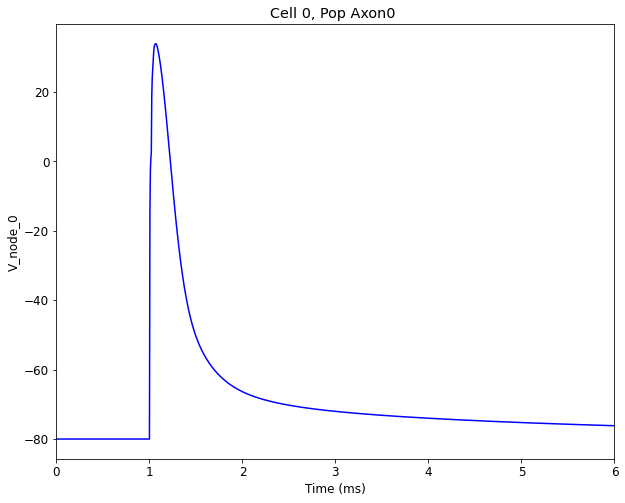

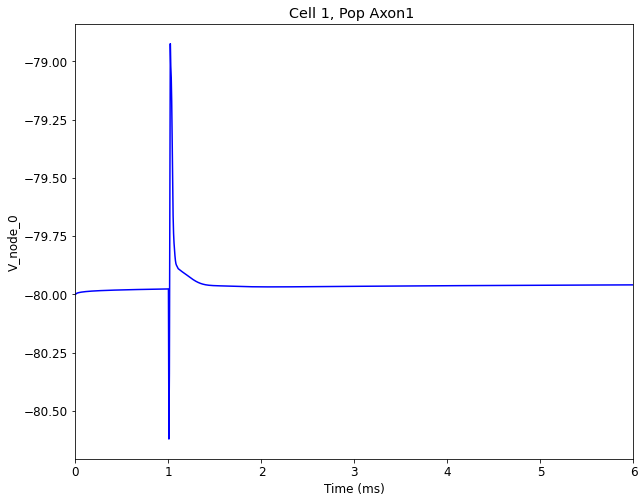

<Figure size 720x576 with 0 Axes>

<Figure size 720x576 with 0 Axes>

Plotting 2D representation of network cell locations and connections...


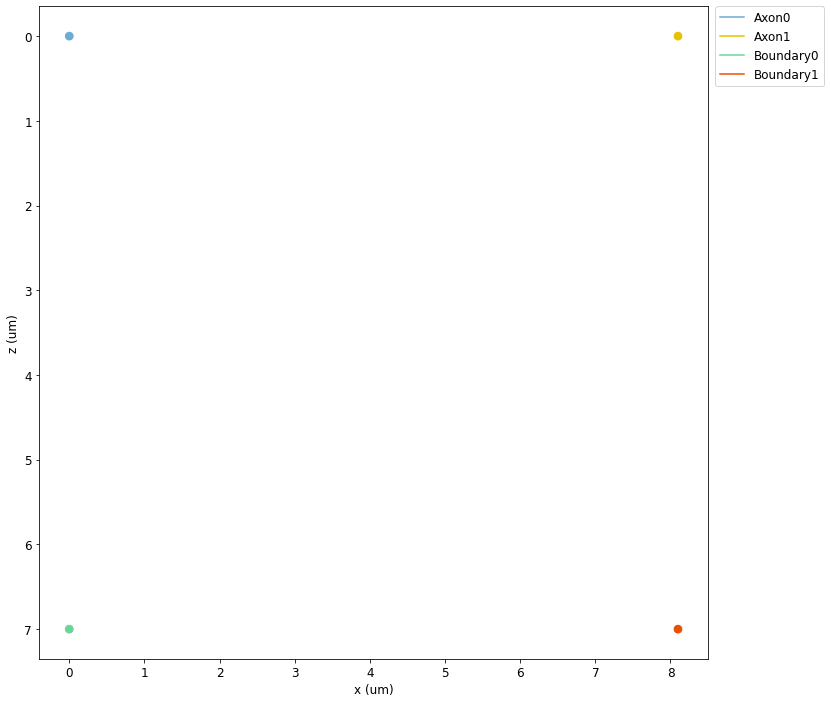

  Done; plotting time = 0.60 s

Total time = 111.71 s

End time:  2023-01-12 00:34:35.307677


In [19]:
sim.simulate()
sim.analyze()

In [20]:
# plotting

#sim.analysis.plotLFP(  plots = ['timeSeries', 'locations'] , electrodes=[ 'all'], lineWidth=1000 ,  fontSize=14, saveFig=True)

# from matplotlib import pyplot
# %matplotlib inline
# pyplot.plot(t, ap1 )
# #pyplot.xlim((0, 10))
# pyplot.show()


In [21]:
# show the execution time

end_time = datetime.now()
print('Duration: {}'.format(end_time - start_time))

Duration: 0:01:55.256321


In [22]:
import csv


with open('xg0changed_MYSA30_il_icap_stimulateonlyAbeta0_edgedist0.1_.csv', 'w', newline='') as f:
     csv.writer(f).writerows(zip( t , Abeta0_il_MYSA30 , Abeta0_icap_MYSA30 ))
        
        
# with open('xg0changed_MYSA30_05_1_vext0_stimulateonlyAbeta0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Abeta0_vext0_05_MYSA30 , Abeta0_vext0_1_MYSA30 ))
    

# with open('MYSARpn1x2_node15_v_1_stimulateonlyAbeta0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Abeta0_v_1_node15 ))        


# with open('MYSARpn1x2_node15_ileak_05_stimulateonlyAbeta0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Abeta0_il_node15 ))
        
        
        

In [23]:
###################Thisssssssssssssssssssssssss


# import csv



# with open('MYSARpn1x2_TransmembraneCurrent_Leak_Leftside_Abeta0_stimulateonlyAbeta0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Abeta0_il_STIN579 , Abeta0_il_STIN580 , Abeta0_il_STIN581 , Abeta0_il_STIN582 , Abeta0_il_STIN583 , Abeta0_il_STIN584 , Abeta0_il_STIN585 , Abeta0_il_STIN586 , Abeta0_il_STIN587 , Abeta0_il_STIN588 , Abeta0_il_STIN589 , Abeta0_il_STIN590 , Abeta0_il_STIN591 , Abeta0_il_STIN592 , Abeta0_il_STIN593 , Abeta0_il_STIN594 , Abeta0_il_STIN595 , Abeta0_il_STIN596 , Abeta0_il_STIN597 , Abeta0_il_STIN598 , Abeta0_il_STIN599 , Abeta0_il_FLUT145 , Abeta0_il_FLUT146 , Abeta0_il_FLUT147 , Abeta0_il_FLUT148 , Abeta0_il_FLUT149 , Abeta0_il_MYSA29   ))                 


# with open('MYSARpn1x2_TransmembraneCurrent_Capacitive_Leftside_Abeta0_stimulateonlyAbeta0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Abeta0_icap_STIN579 , Abeta0_icap_STIN580 , Abeta0_icap_STIN581 , Abeta0_icap_STIN582 , Abeta0_icap_STIN583 , Abeta0_icap_STIN584 , Abeta0_icap_STIN585 , Abeta0_icap_STIN586 , Abeta0_icap_STIN587 , Abeta0_icap_STIN588 , Abeta0_icap_STIN589 , Abeta0_icap_STIN590 , Abeta0_icap_STIN591 , Abeta0_icap_STIN592 , Abeta0_icap_STIN593 , Abeta0_icap_STIN594 , Abeta0_icap_STIN595 , Abeta0_icap_STIN596 , Abeta0_icap_STIN597 , Abeta0_icap_STIN598 , Abeta0_il_STIN599 , Abeta0_icap_FLUT145 , Abeta0_icap_FLUT146 , Abeta0_icap_FLUT147 , Abeta0_icap_FLUT148 , Abeta0_icap_FLUT149 , Abeta0_icap_MYSA29   ))                 



# with open('MYSARpn1x2_TransmembraneCurrent_Leak_Rightside_Abeta0_stimulateonlyAbeta0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Abeta0_il_STIN620 , Abeta0_il_STIN619 , Abeta0_il_STIN618 , Abeta0_il_STIN617 , Abeta0_il_STIN616 , Abeta0_il_STIN615 , Abeta0_il_STIN614 , Abeta0_il_STIN613 , Abeta0_il_STIN612 , Abeta0_il_STIN611 , Abeta0_il_STIN610 , Abeta0_il_STIN609 , Abeta0_il_STIN608 , Abeta0_il_STIN607 , Abeta0_il_STIN606 , Abeta0_il_STIN605 , Abeta0_il_STIN604 , Abeta0_il_STIN603 , Abeta0_il_STIN602 , Abeta0_il_STIN601 , Abeta0_il_STIN600 , Abeta0_il_FLUT154 , Abeta0_il_FLUT153 , Abeta0_il_FLUT152 , Abeta0_il_FLUT151 , Abeta0_il_FLUT150 , Abeta0_il_MYSA30   ))                 

        
# with open('MYSARpn1x2_TransmembraneCurrent_Capacitive_Rightside_Abeta0_stimulateonlyAbeta0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Abeta0_icap_STIN620 , Abeta0_icap_STIN619 , Abeta0_icap_STIN618 , Abeta0_icap_STIN617 , Abeta0_icap_STIN616 , Abeta0_icap_STIN615 , Abeta0_icap_STIN614 , Abeta0_icap_STIN613 , Abeta0_icap_STIN612 , Abeta0_icap_STIN611 , Abeta0_icap_STIN610 , Abeta0_icap_STIN609 , Abeta0_icap_STIN608 , Abeta0_icap_STIN607 , Abeta0_icap_STIN606 , Abeta0_icap_STIN605 , Abeta0_icap_STIN604 , Abeta0_icap_STIN603 , Abeta0_icap_STIN602 , Abeta0_icap_STIN601 , Abeta0_icap_STIN600 , Abeta0_icap_FLUT154 , Abeta0_icap_FLUT153 , Abeta0_icap_FLUT152 , Abeta0_icap_FLUT151 , Abeta0_icap_FLUT150 , Abeta0_icap_MYSA30   ))                 
        
        
# #####        

# with open('MYSARpn1x2_vext0_Leftside_Abeta0_stimulateonlyAbeta0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Abeta0_vext0_05_STIN579 , Abeta0_vext0_1_STIN579 , Abeta0_vext0_05_STIN580 , Abeta0_vext0_1_STIN580 , Abeta0_vext0_05_STIN581 , Abeta0_vext0_1_STIN581 , Abeta0_vext0_05_STIN582 , Abeta0_vext0_1_STIN582 , Abeta0_vext0_05_STIN583 , Abeta0_vext0_1_STIN583 , Abeta0_vext0_05_STIN584 , Abeta0_vext0_1_STIN584 , Abeta0_vext0_05_STIN585 , Abeta0_vext0_1_STIN585 , Abeta0_vext0_05_STIN586 , Abeta0_vext0_1_STIN586 , Abeta0_vext0_05_STIN587 , Abeta0_vext0_1_STIN587 , Abeta0_vext0_05_STIN588 , Abeta0_vext0_1_STIN588 , Abeta0_vext0_05_STIN589 , Abeta0_vext0_1_STIN589 , Abeta0_vext0_05_STIN590 , Abeta0_vext0_1_STIN590 , Abeta0_vext0_05_STIN591 , Abeta0_vext0_1_STIN591 , Abeta0_vext0_05_STIN592 , Abeta0_vext0_1_STIN592 , Abeta0_vext0_05_STIN593 , Abeta0_vext0_1_STIN593 , Abeta0_vext0_05_STIN594 , Abeta0_vext0_1_STIN594 , Abeta0_vext0_05_STIN595 , Abeta0_vext0_1_STIN595 , Abeta0_vext0_05_STIN596 , Abeta0_vext0_1_STIN596 , Abeta0_vext0_05_STIN597 , Abeta0_vext0_1_STIN597 , Abeta0_vext0_05_STIN598 , Abeta0_vext0_1_STIN598 , Abeta0_vext0_05_STIN599 , Abeta0_vext0_1_STIN599 , Abeta0_vext0_05_FLUT145 , Abeta0_vext0_1_FLUT145 , Abeta0_vext0_05_FLUT146 , Abeta0_vext0_1_FLUT146 , Abeta0_vext0_05_FLUT147 , Abeta0_vext0_1_FLUT147 , Abeta0_vext0_05_FLUT148 , Abeta0_vext0_1_FLUT148 , Abeta0_vext0_05_FLUT149 , Abeta0_vext0_1_FLUT149 , Abeta0_vext0_05_MYSA29 , Abeta0_vext0_1_MYSA29 , Abeta0_vext0_05_node15 )) 
                                 
                                 
                                 

# with open('MYSARpn1x2_vext0_Rightside_Abeta0_stimulateonlyAbeta0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Abeta0_vext0_05_STIN620 , Abeta0_vext0_1_STIN619 , Abeta0_vext0_05_STIN619 , Abeta0_vext0_1_STIN618 , Abeta0_vext0_05_STIN618 , Abeta0_vext0_1_STIN617 , Abeta0_vext0_05_STIN617 , Abeta0_vext0_1_STIN616 , Abeta0_vext0_05_STIN616 , Abeta0_vext0_1_STIN615 , Abeta0_vext0_05_STIN615 , Abeta0_vext0_1_STIN614 , Abeta0_vext0_05_STIN614 , Abeta0_vext0_1_STIN613 , Abeta0_vext0_05_STIN613 , Abeta0_vext0_1_STIN612 , Abeta0_vext0_05_STIN612 , Abeta0_vext0_1_STIN611 , Abeta0_vext0_05_STIN611 , Abeta0_vext0_1_STIN610 , Abeta0_vext0_05_STIN610 , Abeta0_vext0_1_STIN609 , Abeta0_vext0_05_STIN609 , Abeta0_vext0_1_STIN608 , Abeta0_vext0_05_STIN608 , Abeta0_vext0_1_STIN607 , Abeta0_vext0_05_STIN607 , Abeta0_vext0_1_STIN606 , Abeta0_vext0_05_STIN606 , Abeta0_vext0_1_STIN605 , Abeta0_vext0_05_STIN605 , Abeta0_vext0_1_STIN604 , Abeta0_vext0_05_STIN604 , Abeta0_vext0_1_STIN603 , Abeta0_vext0_05_STIN603 , Abeta0_vext0_1_STIN602 , Abeta0_vext0_05_STIN602 , Abeta0_vext0_1_STIN601 , Abeta0_vext0_05_STIN601 , Abeta0_vext0_1_STIN600 , Abeta0_vext0_05_STIN600 , Abeta0_vext0_1_FLUT154 , Abeta0_vext0_05_FLUT154 , Abeta0_vext0_1_FLUT153 , Abeta0_vext0_05_FLUT153 , Abeta0_vext0_1_FLUT152 , Abeta0_vext0_05_FLUT152 , Abeta0_vext0_1_FLUT151 , Abeta0_vext0_05_FLUT151 , Abeta0_vext0_1_FLUT150 , Abeta0_vext0_05_FLUT150 , Abeta0_vext0_1_MYSA30 , Abeta0_vext0_05_MYSA30 , Abeta0_vext0_1_node15 , Abeta0_vext0_05_node15 )) 
                                 
                                 
                                   
# #####                                
                                 
# with open('MYSARpn1x2_vext1_Leftside_Abeta0_stimulateonlyAbeta0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Abeta0_vext1_05_STIN579 , Abeta0_vext1_1_STIN579 , Abeta0_vext1_05_STIN580 , Abeta0_vext1_1_STIN580 , Abeta0_vext1_05_STIN581 , Abeta0_vext1_1_STIN581 , Abeta0_vext1_05_STIN582 , Abeta0_vext1_1_STIN582 , Abeta0_vext1_05_STIN583 , Abeta0_vext1_1_STIN583 , Abeta0_vext1_05_STIN584 , Abeta0_vext1_1_STIN584 , Abeta0_vext1_05_STIN585 , Abeta0_vext1_1_STIN585 , Abeta0_vext1_05_STIN586 , Abeta0_vext1_1_STIN586 , Abeta0_vext1_05_STIN587 , Abeta0_vext1_1_STIN587 , Abeta0_vext1_05_STIN588 , Abeta0_vext1_1_STIN588 , Abeta0_vext1_05_STIN589 , Abeta0_vext1_1_STIN589 , Abeta0_vext1_05_STIN590 , Abeta0_vext1_1_STIN590 , Abeta0_vext1_05_STIN591 , Abeta0_vext1_1_STIN591 , Abeta0_vext1_05_STIN592 , Abeta0_vext1_1_STIN592 , Abeta0_vext1_05_STIN593 , Abeta0_vext1_1_STIN593 , Abeta0_vext1_05_STIN594 , Abeta0_vext1_1_STIN594 , Abeta0_vext1_05_STIN595 , Abeta0_vext1_1_STIN595 , Abeta0_vext1_05_STIN596 , Abeta0_vext1_1_STIN596 , Abeta0_vext1_05_STIN597 , Abeta0_vext1_1_STIN597 , Abeta0_vext1_05_STIN598 , Abeta0_vext1_1_STIN598 , Abeta0_vext1_05_STIN599 , Abeta0_vext1_1_STIN599 , Abeta0_vext1_05_FLUT145 , Abeta0_vext1_1_FLUT145 , Abeta0_vext1_05_FLUT146 , Abeta0_vext1_1_FLUT146 , Abeta0_vext1_05_FLUT147 , Abeta0_vext1_1_FLUT147 , Abeta0_vext1_05_FLUT148 , Abeta0_vext1_1_FLUT148 , Abeta0_vext1_05_FLUT149 , Abeta0_vext1_1_FLUT149 , Abeta0_vext1_05_MYSA29 , Abeta0_vext1_1_MYSA29 , Abeta0_vext1_05_node15  )) 
                                 
                                 
                                 

# with open('MYSARpn1x2_vext1_Rightside_Abeta0_stimulateonlyAbeta0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Abeta0_vext1_05_STIN620 , Abeta0_vext1_1_STIN619 , Abeta0_vext1_05_STIN619 , Abeta0_vext1_1_STIN618 , Abeta0_vext1_05_STIN618 , Abeta0_vext1_1_STIN617 , Abeta0_vext1_05_STIN617 , Abeta0_vext1_1_STIN616 , Abeta0_vext1_05_STIN616 , Abeta0_vext1_1_STIN615 , Abeta0_vext1_05_STIN615 , Abeta0_vext1_1_STIN614 , Abeta0_vext1_05_STIN614 , Abeta0_vext1_1_STIN613 , Abeta0_vext1_05_STIN613 , Abeta0_vext1_1_STIN612 , Abeta0_vext1_05_STIN612 , Abeta0_vext1_1_STIN611 , Abeta0_vext1_05_STIN611 , Abeta0_vext1_1_STIN610 , Abeta0_vext1_05_STIN610 , Abeta0_vext1_1_STIN609 , Abeta0_vext1_05_STIN609 , Abeta0_vext1_1_STIN608 , Abeta0_vext1_05_STIN608 , Abeta0_vext1_1_STIN607 , Abeta0_vext1_05_STIN607 , Abeta0_vext1_1_STIN606 , Abeta0_vext1_05_STIN606 , Abeta0_vext1_1_STIN605 , Abeta0_vext1_05_STIN605 , Abeta0_vext1_1_STIN604 , Abeta0_vext1_05_STIN604 , Abeta0_vext1_1_STIN603 , Abeta0_vext1_05_STIN603 , Abeta0_vext1_1_STIN602 , Abeta0_vext1_05_STIN602 , Abeta0_vext1_1_STIN601 , Abeta0_vext1_05_STIN601 , Abeta0_vext1_1_STIN600 , Abeta0_vext1_05_STIN600 , Abeta0_vext1_1_FLUT154 , Abeta0_vext1_05_FLUT154 , Abeta0_vext1_1_FLUT153 , Abeta0_vext1_05_FLUT153 , Abeta0_vext1_1_FLUT152 , Abeta0_vext1_05_FLUT152 , Abeta0_vext1_1_FLUT151 , Abeta0_vext1_05_FLUT151 , Abeta0_vext1_1_FLUT150 , Abeta0_vext1_05_FLUT150 , Abeta0_vext1_1_MYSA30 , Abeta0_vext1_05_MYSA30 , Abeta0_vext1_1_node15 , Abeta0_vext1_05_node15 )) 
                                
                                            
# #####


# with open('MYSARpn1x2_Boundary_stimulateonlyAbeta0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , boundary0_vext1_section1663 ))
                                            
                                       
# with open('MYSARpn1x2_vext1_Abeta1_stimulateonlyAbeta0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Abeta1_vext1_05_node15  ))
                                            
                                     
# with open('MYSARpn1x2_ina_Node15Abeta0_stimulateonlyAbeta0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t ,  Abeta0_ina_node15 ))                                 
                                 
                                 
# with open('MYSARpn1x2_icap_Node15Abeta0_stimulateonlyAbeta0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t ,  Abeta0_icap_node15 ))                                 
                                 
                               
                                 
                                 

In [24]:
# Longitudinal Current: picoamp

print(xr)
print(Rpn0)
# xraxia = xr*1e6   #ohm/cm
# xraxia = xraxia*2*1e-4    # ohm,  length between node to MYSA is 2 micron


# v_diff_00 = (Abeta0_vext1_node0-Abeta0_vext1_MYSA0)/1000     #volt
# Longi_Current_node0_MYSA0 = v_diff_00/xraxia   #amp
# Longi_Current_node0_MYSA0 = Longi_Current_node0_MYSA0*1e12   #picoamp

# v_diff_12 = (Abeta0_vext1_node1-Abeta0_vext1_MYSA2)/1000     #volt
# Longi_Current_node1_MYSA2 = v_diff_12/xraxia   
# Longi_Current_node1_MYSA2 = Longi_Current_node1_MYSA2*1e12   

# v_diff_24 = (Abeta0_vext1_node2-Abeta0_vext1_MYSA4)/1000     #volt
# Longi_Current_node2_MYSA4 = v_diff_24/xraxia  
# Longi_Current_node2_MYSA4 = Longi_Current_node2_MYSA4*1e12  




# v_diff_36 = (Abeta0_vext1_node3-Abeta0_vext1_MYSA6)




# # v_diff_36 = (Abeta0_vext1_node3-Abeta0_vext1_MYSA6)/1000     #volt
# # Longi_Current_node3_MYSA6 = v_diff_36/xraxia   
# # Longi_Current_node3_MYSA6 = Longi_Current_node3_MYSA6*1e12  

# v_diff_48 = (Abeta0_vext1_node4-Abeta0_vext1_MYSA8)/1000     #volt
# Longi_Current_node4_MYSA8 = v_diff_48/xraxia  
# Longi_Current_node4_MYSA8 = Longi_Current_node4_MYSA8*1e12  

# v_diff_510 = (Abeta0_vext1_node5-Abeta0_vext1_MYSA10)/1000     #volt
# Longi_Current_node5_MYSA10 = (v_diff_510/xraxia)*1e12  

# v_diff_612 = (Abeta0_vext1_node6-Abeta0_vext1_MYSA12)/1000     #volt
# Longi_Current_node6_MYSA12 = (v_diff_612/xraxia)*1e12  

# v_diff_714 = (Abeta0_vext1_node7-Abeta0_vext1_MYSA14)/1000     #volt
# Longi_Current_node7_MYSA14 = (v_diff_714/xraxia)*1e12 

# v_diff_816 = (Abeta0_vext1_node8-Abeta0_vext1_MYSA16)/1000     #volt
# Longi_Current_node8_MYSA16 = (v_diff_816/xraxia)*1e12  

# v_diff_918 = (Abeta0_vext1_node9-Abeta0_vext1_MYSA18)/1000     #volt
# Longi_Current_node9_MYSA18 = (v_diff_918/xraxia)*1e12  

# v_diff_1020 = (Abeta0_vext1_node10-Abeta0_vext1_MYSA20)/1000     #volt
# Longi_Current_node10_MYSA20 = (v_diff_1020/xraxia)*1e12 

# v_diff_1122 = (Abeta0_vext1_node11-Abeta0_vext1_MYSA22)/1000     #volt
# Longi_Current_node11_MYSA22 = (v_diff_1122/xraxia)*1e12  


95769.75706051444
429128.527578172


In [25]:
# Transverse current: Picoamp/micron^2


# v_diff00 = (Abeta0_vext1_node0 - Abeta1_vext1_node0)/1000    #volt
# Trans_Current_node0_node0 = (v_diff00 * 6.9e+04 )*1e12/1e8  #volt*S/cm2 = Amp/cm2 = PicoAMP/cm2 = PicoAMP/micron^2

# v_diff11 = (Abeta0_vext1_node1 - Abeta1_vext1_node1)/1000    #volt
# Trans_Current_node1_node1 = v_diff11 * 6.9e+04 *1e12/1e8   

# v_diff22 = (Abeta0_vext1_node2 - Abeta1_vext1_node2)/1000    #volt
# Trans_Current_node2_node2 = v_diff22 * 6.9e+04 *1e12/1e8  

# v_diff33 = (Abeta0_vext1_node3 - Abeta1_vext1_node3)/1000    #volt
# Trans_Current_node3_node3 = v_diff33 * 6.9e+04 *1e12/1e8  

# v_diff44 = (Abeta0_vext1_node4 - Abeta1_vext1_node4)/1000    #volt
# Trans_Current_node4_node4 = v_diff44 * 6.9e+04 *1e12/1e8  

# v_diff55 = (Abeta0_vext1_node5 - Abeta1_vext1_node5)/1000    #volt
# Trans_Current_node5_node5 = v_diff55 * 6.9e+04 *1e12/1e8  

# v_diff66 = (Abeta0_vext1_node6 - Abeta1_vext1_node6)/1000    #volt
# Trans_Current_node6_node6 = v_diff66 * 6.9e+04 *1e12/1e8  

# v_diff77 = (Abeta0_vext1_node7 - Abeta1_vext1_node7)/1000    #volt
# Trans_Current_node7_node7 = v_diff77 * 6.9e+04 *1e12/1e8 

# v_diff88 = (Abeta0_vext1_node8 - Abeta1_vext1_node8)/1000    #volt
# Trans_Current_node8_node8 = v_diff88 * 6.9e+04 *1e12/1e8  

# v_diff99 = (Abeta0_vext1_node9 - Abeta1_vext1_node9)/1000    #volt
# Trans_Current_node9_node9 = v_diff99 * 6.9e+04 *1e12/1e8  

# v_diff1010 = (Abeta0_vext1_node10 - Abeta1_vext1_node10)/1000    #volt
# Trans_Current_node10_node10 = v_diff1010 * 6.9e+04 *1e12/1e8  

# v_diff1111 = (Abeta0_vext1_node11 - Abeta1_vext1_node11)/1000    #volt
# Trans_Current_node11_node11 = v_diff1111 * 6.9e+04 *1e12/1e8  



In [26]:
# import csv

# with open('v_diff66_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , v_diff66 ))
        
        
        
import csv

# with open('ALLExtraVoltages_stimulateonlyAbeta0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Abeta0_vext0_node0515 ,  Abeta0_vext1_node0515  , Abeta0_vext1_node015  , Abeta0_vext1_node115  , Abeta1_vext1_node0515 , boundary0_vext1_section1663 ,  Abeta0_vext0_node115 ,  Abeta0_vext0_MYSA0530 ,  Abeta0_vext1_MYSA0530 , Abeta0_vext0_node015))

        
# with open('MYSAandFLUTExtraVoltages_vext0_stimulateonlyAbeta0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , MYSA30_vext0_0_ , MYSA30_vext0_05_ , MYSA30_vext0_1_ , FLUT150_vext0_05_  , FLUT150_vext0_1_  , FLUT151_vext0_05_  , FLUT151_vext0_1_  , FLUT152_vext0_05_  , FLUT152_vext0_1_  , FLUT153_vext0_05_  , FLUT153_vext0_1_  , FLUT154_vext0_05_  , FLUT154_vext0_1_       ))

            
        
# with open('MYSAandFLUTExtraVoltages_vext1_stimulateonlyAbeta0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , MYSA30_vext1_0_ , MYSA30_vext1_05_ , MYSA30_vext1_1_ , FLUT150_vext1_05_  , FLUT150_vext1_1_  , FLUT151_vext1_05_  , FLUT151_vext1_1_  , FLUT152_vext1_05_  , FLUT152_vext1_1_  , FLUT153_vext1_05_  , FLUT153_vext1_1_  , FLUT154_vext1_05_  , FLUT154_vext1_1_       ))




# with open('STINExtraVoltages_vext0_stimulateonlyAbeta0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Abeta0_vext0_STIN05_600  , Abeta0_vext0_STIN1_600 , Abeta0_vext0_STIN05_601  , Abeta0_vext0_STIN1_601 , Abeta0_vext0_STIN05_602  , Abeta0_vext0_STIN1_602 , Abeta0_vext0_STIN05_603  , Abeta0_vext0_STIN1_603 , Abeta0_vext0_STIN05_604  , Abeta0_vext0_STIN1_604 , Abeta0_vext0_STIN05_605  , Abeta0_vext0_STIN1_605 , Abeta0_vext0_STIN05_606  , Abeta0_vext0_STIN1_606 , Abeta0_vext0_STIN05_607  , Abeta0_vext0_STIN1_607 , Abeta0_vext0_STIN05_608  , Abeta0_vext0_STIN1_608 , Abeta0_vext0_STIN05_609  , Abeta0_vext0_STIN1_609 , Abeta0_vext0_STIN05_610  , Abeta0_vext0_STIN1_610 , Abeta0_vext0_STIN05_611  , Abeta0_vext0_STIN1_611 , Abeta0_vext0_STIN05_612  , Abeta0_vext0_STIN1_612, Abeta0_vext0_STIN05_613  , Abeta0_vext0_STIN1_613, Abeta0_vext0_STIN05_614  , Abeta0_vext0_STIN1_614 , Abeta0_vext0_STIN05_615  , Abeta0_vext0_STIN1_615 , Abeta0_vext0_STIN05_616  , Abeta0_vext0_STIN1_616 , Abeta0_vext0_STIN05_617  , Abeta0_vext0_STIN1_617 , Abeta0_vext0_STIN05_618  , Abeta0_vext0_STIN1_618 , Abeta0_vext0_STIN05_619  , Abeta0_vext0_STIN1_619, Abeta0_vext0_STIN05_620  , Abeta0_vext0_STIN1_620, Abeta0_vext0_STIN05_621  , Abeta0_vext0_STIN1_621 , Abeta0_vext0_STIN05_622  , Abeta0_vext0_STIN1_622 , Abeta0_vext0_STIN05_623  , Abeta0_vext0_STIN1_623 , Abeta0_vext0_STIN05_624  , Abeta0_vext0_STIN1_624 , Abeta0_vext0_STIN05_625  , Abeta0_vext0_STIN1_625 , Abeta0_vext0_STIN05_626  , Abeta0_vext0_STIN1_626, Abeta0_vext0_STIN05_627  , Abeta0_vext0_STIN1_627, Abeta0_vext0_STIN05_628  , Abeta0_vext0_STIN1_628, Abeta0_vext0_STIN05_629  , Abeta0_vext0_STIN1_629, Abeta0_vext0_STIN05_630  , Abeta0_vext0_STIN1_630 , Abeta0_vext0_STIN05_631  , Abeta0_vext0_STIN1_631, Abeta0_vext0_STIN05_632  , Abeta0_vext0_STIN1_632, Abeta0_vext0_STIN05_633  , Abeta0_vext0_STIN1_633 , Abeta0_vext0_STIN05_634  , Abeta0_vext0_STIN1_634 , Abeta0_vext0_STIN05_635  , Abeta0_vext0_STIN1_635 , Abeta0_vext0_STIN05_636  , Abeta0_vext0_STIN1_636, Abeta0_vext0_STIN05_637  , Abeta0_vext0_STIN1_637, Abeta0_vext0_STIN05_638  , Abeta0_vext0_STIN1_638 , Abeta0_vext0_STIN05_639  , Abeta0_vext0_STIN1_639 ))         
                                 
                                 
# with open('STINExtraVoltages_vext1_stimulateonlyAbeta0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Abeta0_vext1_STIN05_600  , Abeta0_vext1_STIN1_600 , Abeta0_vext1_STIN05_601  , Abeta0_vext1_STIN1_601 , Abeta0_vext1_STIN05_602  , Abeta0_vext1_STIN1_602 , Abeta0_vext1_STIN05_603  , Abeta0_vext1_STIN1_603 , Abeta0_vext1_STIN05_604  , Abeta0_vext1_STIN1_604 , Abeta0_vext1_STIN05_605  , Abeta0_vext1_STIN1_605 , Abeta0_vext1_STIN05_606  , Abeta0_vext1_STIN1_606 , Abeta0_vext1_STIN05_607  , Abeta0_vext1_STIN1_607 , Abeta0_vext1_STIN05_608  , Abeta0_vext1_STIN1_608 , Abeta0_vext1_STIN05_609  , Abeta0_vext1_STIN1_609 , Abeta0_vext1_STIN05_610  , Abeta0_vext1_STIN1_610 , Abeta0_vext1_STIN05_611  , Abeta0_vext1_STIN1_611 , Abeta0_vext1_STIN05_612  , Abeta0_vext1_STIN1_612, Abeta0_vext1_STIN05_613  , Abeta0_vext1_STIN1_613, Abeta0_vext1_STIN05_614  , Abeta0_vext1_STIN1_614 , Abeta0_vext1_STIN05_615  , Abeta0_vext1_STIN1_615 , Abeta0_vext1_STIN05_616  , Abeta0_vext1_STIN1_616 , Abeta0_vext1_STIN05_617  , Abeta0_vext1_STIN1_617 , Abeta0_vext1_STIN05_618  , Abeta0_vext1_STIN1_618 , Abeta0_vext1_STIN05_619  , Abeta0_vext1_STIN1_619, Abeta0_vext1_STIN05_620  , Abeta0_vext1_STIN1_620, Abeta0_vext1_STIN05_621  , Abeta0_vext1_STIN1_621 , Abeta0_vext1_STIN05_622  , Abeta0_vext1_STIN1_622 , Abeta0_vext1_STIN05_623  , Abeta0_vext1_STIN1_623 , Abeta0_vext1_STIN05_624  , Abeta0_vext1_STIN1_624 , Abeta0_vext1_STIN05_625  , Abeta0_vext1_STIN1_625 , Abeta0_vext1_STIN05_626  , Abeta0_vext1_STIN1_626, Abeta0_vext1_STIN05_627  , Abeta0_vext1_STIN1_627, Abeta0_vext1_STIN05_628  , Abeta0_vext1_STIN1_628, Abeta0_vext1_STIN05_629  , Abeta0_vext1_STIN1_629, Abeta0_vext1_STIN05_630  , Abeta0_vext1_STIN1_630 , Abeta0_vext1_STIN05_631  , Abeta0_vext1_STIN1_631, Abeta0_vext1_STIN05_632  , Abeta0_vext1_STIN1_632, Abeta0_vext1_STIN05_633  , Abeta0_vext1_STIN1_633 , Abeta0_vext1_STIN05_634  , Abeta0_vext1_STIN1_634 , Abeta0_vext1_STIN05_635  , Abeta0_vext1_STIN1_635 , Abeta0_vext1_STIN05_636  , Abeta0_vext1_STIN1_636, Abeta0_vext1_STIN05_637  , Abeta0_vext1_STIN1_637, Abeta0_vext1_STIN05_638  , Abeta0_vext1_STIN1_638 , Abeta0_vext1_STIN05_639  , Abeta0_vext1_STIN1_639 ))         
                                 
                                        
                                 
                                 
                                 
                                 
                                 

In [27]:
# I1 =  (Abeta0_vext1_node15 - Abeta0_vext1_MYSA30)/(xr*2*1e6)              #(Vext1-Vext2)/xr*2*1e6    #mA.cm
# I2 =  (Abeta0_vext1_node15 - Abeta1_vext1_node15)*(7.08e+04)     #mA/cm2   (Vext1-Vext3)
# I3 =  (Abeta0_vext1_MYSA29 - Abeta0_vext1_node15)/(xr*2*1e6)     #mA.cm    (Vext4-Vext1)                                                                (Vext4-Vext1)
# I4 =  (Abeta0_vext0_node15 - Abeta0_vext1_node15)*1e6           #mA/cm2   (Vext5-Vext1)
# I5 =  (Abeta0_vext0_node15 - Abeta0_vext0_MYSA30)/(Rpn0*2*1e6)                   #mA.cm    (Vext5-Vext6)
# I6 =  (Abeta0_vext0_MYSA29 - Abeta0_vext0_node15 )/(Rpn0*2*1e6)                   #mA.cm    (Vext5-Vext6)    
# I7 =  (Abeta0_vext0_MYSA30 - Abeta0_vext1_MYSA30 )*(mygm/(nl*2))   #mA/cm2   (Vext6-Vext2)
# I8 =  (Abeta0_vext0_MYSA29 - Abeta0_vext1_MYSA29 )*(mygm/(nl*2))   #mA/cm2   (Vext7-Vext4)


# V62 = (Abeta0_vext0_MYSA30 - Abeta0_vext1_MYSA30 )
# I9 = np.gradient(V62,0.005)*mycm/(nl*2)                # C dv/dt

# V74 = (Abeta0_vext0_MYSA29 - Abeta0_vext1_MYSA29 )
# I10 = np.gradient(V74,0.005)*mycm/(nl*2)


In [28]:
# import csv

# with open('ALLCurrents_stimulateonlyAbeta0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , I1 )
    

#### saving the data

In [29]:
## saving the data


import csv









# ####################################  Connected to ground 

# with open('Rpn1x2_v_Abeta0_stimulateonlyAbeta0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Abeta0_v_node0 , Abeta0_v_node1 , Abeta0_v_node2 , Abeta0_v_node3 , Abeta0_v_node4 , Abeta0_v_node5 , Abeta0_v_node6 , Abeta0_v_node7 , Abeta0_v_node8 , Abeta0_v_node9 , Abeta0_v_node10 , Abeta0_v_node11 )) 



# with open('ConnectGround_LongiCurrent_Abeta0_NodetoMYSA_stimulateonlyAbeta0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Longi_Current_node0_MYSA0 , Longi_Current_node1_MYSA2 , Longi_Current_node2_MYSA4 , Longi_Current_node3_MYSA6 , Longi_Current_node4_MYSA8 , Longi_Current_node5_MYSA10 , Longi_Current_node6_MYSA12 , Longi_Current_node7_MYSA14 , Longi_Current_node8_MYSA16 , Longi_Current_node9_MYSA18 , Longi_Current_node10_MYSA20 , Longi_Current_node11_MYSA22   ))
    
    

# with open('ConnectGround_TransCurrent_stimulateonlyAbeta0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Trans_Current_node0_node0 , Trans_Current_node1_node1 , Trans_Current_node2_node2 , Trans_Current_node3_node3 , Trans_Current_node4_node4 , Trans_Current_node5_node5 , Trans_Current_node6_node6 , Trans_Current_node7_node7 , Trans_Current_node8_node8 , Trans_Current_node9_node9 , Trans_Current_node10_node10 , Trans_Current_node11_node11 ))






    
# ##################################### Not connected to ground, Stimulate only one fiber     


   
# with open('vext1_Abeta1_stimulateonlyAbeta0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Abeta0_vext1_node0 , Abeta0_vext1_node1 , Abeta0_vext1_node2 , Abeta0_vext1_node3 , Abeta0_vext1_node4 , Abeta0_vext1_node5 , Abeta0_vext1_node6 , Abeta0_vext1_node7 , Abeta0_vext1_node8 , Abeta0_vext1_node9 , Abeta0_vext1_node10 , Abeta0_vext1_node11 , Abeta0_vext1_node12 , Abeta0_vext1_node13 , Abeta0_vext1_node14 , Abeta0_vext1_node15 , Abeta0_vext1_node16 , Abeta0_vext1_node17 , Abeta0_vext1_node18 , Abeta0_vext1_node19 , Abeta0_vext1_node20 , Abeta0_vext1_node21 , Abeta0_vext1_node22 , Abeta0_vext1_node23 , Abeta0_vext1_node24 , Abeta0_vext1_node25 , Abeta0_vext1_node26 , Abeta0_vext1_node27 , Abeta0_vext1_node28 , Abeta0_vext1_node29 , Abeta0_vext1_node30 , Abeta0_vext1_node31 , Abeta0_vext1_node32 , Abeta0_vext1_node33 , Abeta0_vext1_node34 , Abeta0_vext1_node35 )) 
        
        
        
# with open('Rpn1x2_xg0ofnodeChanged_Abeta0_stimulateonlyAbeta0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Abeta0_v_node0 , Abeta0_v_node1 , Abeta0_v_node2 , Abeta0_v_node3 , Abeta0_v_node4 , Abeta0_v_node5 , Abeta0_v_node6 , Abeta0_v_node7 , Abeta0_v_node8 , Abeta0_v_node9 , Abeta0_v_node10 , Abeta0_v_node11 , Abeta0_v_node12 , Abeta0_v_node13 , Abeta0_v_node14 , Abeta0_v_node15 , Abeta0_v_node16 , Abeta0_v_node17 , Abeta0_v_node18 , Abeta0_v_node19 , Abeta0_v_node20 , Abeta0_v_node21 , Abeta0_v_node22 , Abeta0_v_node23 , Abeta0_v_node24 , Abeta0_v_node25 , Abeta0_v_node26 , Abeta0_v_node27 , Abeta0_v_node28 , Abeta0_v_node29 , Abeta0_v_node30 , Abeta0_v_node31 , Abeta0_v_node32 , Abeta0_v_node33 , Abeta0_v_node34 , Abeta0_v_node35 )) 


        
        
# with open('imembrane_Abeta0_stimulateBOTH_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Abeta0_imembrane_node0 , Abeta0_imembrane_node1 , Abeta0_imembrane_node2 , Abeta0_imembrane_node3 , Abeta0_imembrane_node4 , Abeta0_imembrane_node5 , Abeta0_imembrane_node6 , Abeta0_imembrane_node7 , Abeta0_imembrane_node8 , Abeta0_imembrane_node9 , Abeta0_imembrane_node10 , Abeta0_imembrane_node11 , Abeta0_imembrane_node12 , Abeta0_imembrane_node13 , Abeta0_imembrane_node14 , Abeta0_imembrane_node15 , Abeta0_imembrane_node16 , Abeta0_imembrane_node17 , Abeta0_imembrane_node18 , Abeta0_imembrane_node19 , Abeta0_imembrane_node20 , Abeta0_imembrane_node21 , Abeta0_imembrane_node22 , Abeta0_imembrane_node23 , Abeta0_imembrane_node24 , Abeta0_imembrane_node25 , Abeta0_imembrane_node26 , Abeta0_imembrane_node27 , Abeta0_imembrane_node28 , Abeta0_imembrane_node29 , Abeta0_imembrane_node30 , Abeta0_imembrane_node31 , Abeta0_imembrane_node32 , Abeta0_imembrane_node33 , Abeta0_imembrane_node34 , Abeta0_imembrane_node35 )) 
        
        
    
        
# with open('i_Abeta0_stimulateBOTH_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Abeta0_v_node0 , Abeta0_v_node1 , Abeta0_v_node2 , Abeta0_v_node3 , Abeta0_v_node4 , Abeta0_v_node5 , Abeta0_v_node6 , Abeta0_v_node7 , Abeta0_v_node8 , Abeta0_v_node9 , Abeta0_v_node10 , Abeta0_v_node11 )) 


# with open('LongiCurrent_Abeta0_NodetoMYSA_stimulateonlyAbeta0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Longi_Current_node0_MYSA0 , Longi_Current_node1_MYSA2 , Longi_Current_node2_MYSA4 , Longi_Current_node3_MYSA6 , Longi_Current_node4_MYSA8 , Longi_Current_node5_MYSA10 , Longi_Current_node6_MYSA12 , Longi_Current_node7_MYSA14 , Longi_Current_node8_MYSA16 , Longi_Current_node9_MYSA18 , Longi_Current_node10_MYSA20 , Longi_Current_node11_MYSA22   ))
    
    

# with open('TransCurrent_stimulateonlyAbeta0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Trans_Current_node0_node0 , Trans_Current_node1_node1 , Trans_Current_node2_node2 , Trans_Current_node3_node3 , Trans_Current_node4_node4 , Trans_Current_node5_node5 , Trans_Current_node6_node6 , Trans_Current_node7_node7 , Trans_Current_node8_node8 , Trans_Current_node9_node9 , Trans_Current_node10_node10 , Trans_Current_node11_node11 ))
    
    
    
# with open('v_Abeta1_stimulateonlyAbeta0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Abeta1_v_node0 , Abeta1_v_node1 , Abeta1_v_node2 , Abeta1_v_node3 , Abeta1_v_node4 , Abeta1_v_node5 , Abeta1_v_node6 , Abeta1_v_node7 , Abeta1_v_node8 , Abeta1_v_node9 , Abeta1_v_node10 , Abeta1_v_node11 )) 
    
    
    
    
    
# ##################################### Not connected to ground, Stimulate BOTH fibers    


# with open('v_Abeta0_stimulateBOTH_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Abeta0_v_node0 , Abeta0_v_node1 , Abeta0_v_node2 , Abeta0_v_node3 , Abeta0_v_node4 , Abeta0_v_node5 , Abeta0_v_node6 , Abeta0_v_node7 , Abeta0_v_node8 , Abeta0_v_node9 , Abeta0_v_node10 , Abeta0_v_node11 )) 



# with open('LongiCurrent_Abeta0_NodetoMYSA_stimulateBOTH_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Longi_Current_node0_MYSA0 , Longi_Current_node1_MYSA2 , Longi_Current_node2_MYSA4 , Longi_Current_node3_MYSA6 , Longi_Current_node4_MYSA8 , Longi_Current_node5_MYSA10 , Longi_Current_node6_MYSA12 , Longi_Current_node7_MYSA14 , Longi_Current_node8_MYSA16 , Longi_Current_node9_MYSA18 , Longi_Current_node10_MYSA20 , Longi_Current_node11_MYSA22   ))
    
    

# with open('TransCurrent_stimulateBOTH_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Trans_Current_node0_node0 , Trans_Current_node1_node1 , Trans_Current_node2_node2 , Trans_Current_node3_node3 , Trans_Current_node4_node4 , Trans_Current_node5_node5 , Trans_Current_node6_node6 , Trans_Current_node7_node7 , Trans_Current_node8_node8 , Trans_Current_node9_node9 , Trans_Current_node10_node10 , Trans_Current_node11_node11 ))
    
    
    

# with open('Connectground_vext1_Abeta0_stimulateonlyAbeta0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Abeta0_vext1_node0 , Abeta0_vext1_node1 , Abeta0_vext1_node2 , Abeta0_vext1_node3 , Abeta0_vext1_node4 , Abeta0_vext1_node5 , Abeta0_vext1_node6 , Abeta0_vext1_node7 , Abeta0_vext1_node8 , Abeta0_vext1_node9 , Abeta0_vext1_node10 , Abeta0_vext1_node11 )) 
 
    
# with open('vext1_Abeta1_stimulateonlyAbeta0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Abeta1_vext1_node0 , Abeta1_vext1_node1 , Abeta1_vext1_node2 , Abeta1_vext1_node3 , Abeta1_vext1_node4 , Abeta1_vext1_node5 , Abeta1_vext1_node6 , Abeta1_vext1_node7 , Abeta1_vext1_node8 , Abeta1_vext1_node9 , Abeta1_vext1_node10 , Abeta1_vext1_node11 )) 



In [30]:

# with open('STIN220_vext1_Abeta0_stimulateBOTH_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Abeta0_vext1_STIN220))
        
        
# with open('MYSA30_v_Abeta0_stimulateonlyAbeta0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Abeta0_v_MYSA30))        
        
# with open('node15_vext0(0.5)(1)_Abeta0_stimulateonlyAbeta0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Abeta0_vext0_05_node15 , Abeta0_vext0_1_node15))        
        
# with open('node15_vext0(1)_Abeta0_stimulateonlyAbeta0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Abeta0_vext0_1_node15))  
        
# with open('node15_vext1(0.5)(1)_Abeta0_stimulateonlyAbeta0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t  , Abeta0_vext1_05_node15 , Abeta0_vext1_1_node15))    
        
        
        
        
        

In [31]:
   
# with open('icap_Abeta0_stimulateonlyAbata0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Abeta0_icap_node0 , Abeta0_icap_node1 , Abeta0_icap_node2 , Abeta0_icap_node3 , Abeta0_icap_node4 , Abeta0_icap_node5 , Abeta0_icap_node6 , Abeta0_icap_node7 , Abeta0_icap_node8 , Abeta0_icap_node9 , Abeta0_icap_node10 , Abeta0_icap_node11 , Abeta0_icap_node12 , Abeta0_icap_node13 , Abeta0_icap_node14 , Abeta0_icap_node15 , Abeta0_icap_node16 , Abeta0_icap_node17 , Abeta0_icap_node18 , Abeta0_icap_node19 , Abeta0_icap_node20 , Abeta0_icap_node21 , Abeta0_icap_node22 , Abeta0_icap_node23 , Abeta0_icap_node24 , Abeta0_icap_node25)) 

        
        
# with open('ik_Abeta0_stimulateonlyAbata0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Abeta0_ik_node0 , Abeta0_ik_node1 , Abeta0_ik_node2 , Abeta0_ik_node3 , Abeta0_ik_node4 , Abeta0_ik_node5 , Abeta0_ik_node6 , Abeta0_ik_node7 , Abeta0_ik_node8 , Abeta0_ik_node9 , Abeta0_ik_node10 , Abeta0_ik_node11 , Abeta0_ik_node12 , Abeta0_ik_node13 , Abeta0_ik_node14 , Abeta0_ik_node15 , Abeta0_ik_node16 , Abeta0_ik_node17 , Abeta0_ik_node18 , Abeta0_ik_node19 , Abeta0_ik_node20 )) 


        
# with open('il_Abeta0_stimulateonlyAbata0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Abeta0_il_node0 , Abeta0_il_node1 , Abeta0_il_node2 , Abeta0_il_node3 , Abeta0_il_node4 , Abeta0_il_node5 , Abeta0_il_node6 , Abeta0_il_node7 , Abeta0_il_node8 , Abeta0_il_node9 , Abeta0_il_node10 , Abeta0_il_node11, Abeta0_il_node12 , Abeta0_il_node13 , Abeta0_il_node14 , Abeta0_il_node15 , Abeta0_il_node16 , Abeta0_il_node17 , Abeta0_il_node18 , Abeta0_il_node19 , Abeta0_il_node20 )) 


        
# with open('ina_Abeta0_stimulateonlyAbata0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Abeta0_ina_node0 , Abeta0_ina_node1 , Abeta0_ina_node2 , Abeta0_ina_node3 , Abeta0_ina_node4 , Abeta0_ina_node5 , Abeta0_ina_node6 , Abeta0_ina_node7 , Abeta0_ina_node8 , Abeta0_ina_node9 , Abeta0_ina_node10 , Abeta0_ina_node11 , Abeta0_ina_node12 , Abeta0_ina_node13 , Abeta0_ina_node14 , Abeta0_ina_node15 , Abeta0_ina_node16 , Abeta0_ina_node17 , Abeta0_ina_node18 , Abeta0_ina_node19 , Abeta0_ina_node20 )) 


        
# with open('inap_Abeta0_stimulateonlyAbata0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Abeta0_inap_node0 , Abeta0_inap_node1 , Abeta0_inap_node2 , Abeta0_inap_node3 , Abeta0_inap_node4 , Abeta0_inap_node5 , Abeta0_inap_node6 , Abeta0_inap_node7 , Abeta0_inap_node8 , Abeta0_inap_node9 , Abeta0_inap_node10 , Abeta0_inap_node11 , Abeta0_inap_node12 , Abeta0_inap_node13 , Abeta0_inap_node14 , Abeta0_inap_node15 , Abeta0_inap_node16 , Abeta0_inap_node17 , Abeta0_inap_node18 , Abeta0_inap_node19 , Abeta0_inap_node20 )) 

        
        
# with open('ConnectedGround_imembrane_Abeta0_stimulateonlyAbata0_edgedist0.1_.csv', 'w', newline='') as f:
#      csv.writer(f).writerows(zip( t , Abeta0_imembrane_node0 , Abeta0_imembrane_node1 , Abeta0_imembrane_node2 , Abeta0_imembrane_node3 , Abeta0_imembrane_node4 , Abeta0_imembrane_node5 , Abeta0_imembrane_node6 , Abeta0_imembrane_node7 , Abeta0_imembrane_node8 , Abeta0_imembrane_node9 , Abeta0_imembrane_node10 , Abeta0_imembrane_node11 )) 
        
        


In [32]:
print(Rpn2)

108066.18906880693


In [33]:
print(Rpn1)

429128.527578172


In [34]:
print(Rpx)

108066.18906880693
